First, mount your Google Drive to access your files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json
import ast
import warnings
from collections import Counter
import re

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ==============================================================================
# 1. DATA LOADING & INITIAL VALIDATION
# ==============================================================================

def load_and_validate_data(file_path):
    """
    Load dataset and perform initial validation

    Args:
        file_path (str): Path to CSV file

    Returns:
        pd.DataFrame: Loaded dataset
    """
    print("=" * 80)
    print("STEP 1: DATA LOADING & VALIDATION")
    print("=" * 80)

    # Load data
    print(f"\n📂 Loading data from: {file_path}")
    df = pd.read_csv(file_path)

    # Basic info
    print(f"\n✅ Data loaded successfully!")
    print(f"   • Total samples: {len(df):,}")
    print(f"   • Total features: {len(df.columns)}")
    print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Display columns
    print(f"\n📋 Columns:")
    for i, col in enumerate(df.columns, 1):
        print(f"   {i}. {col} ({df[col].dtype})")

    # First few rows
    print(f"\n👀 First 3 samples:")
    print(df.head(3).to_string())

    return df


def check_missing_values(df):
    """
    Comprehensive missing value analysis

    Args:
        df (pd.DataFrame): Dataset
    """
    print("\n" + "=" * 80)
    print("STEP 2: MISSING VALUE ANALYSIS")
    print("=" * 80)

    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100

    missing_df = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': missing.values,
        'Missing_Percentage': missing_pct.values
    })

    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(
        'Missing_Count', ascending=False
    )

    if len(missing_df) == 0:
        print("\n✅ No missing values found! Dataset is complete.")
    else:
        print(f"\n⚠️  Found missing values in {len(missing_df)} columns:")
        print(missing_df.to_string(index=False))

        # Visualize
        if len(missing_df) > 0:
            plt.figure(figsize=(10, 6))
            plt.barh(missing_df['Column'], missing_df['Missing_Percentage'])
            plt.xlabel('Missing Percentage (%)')
            plt.title('Missing Values Analysis')
            plt.tight_layout()
            plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/01_missing_values.png', dpi=300, bbox_inches='tight')
            print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/01_missing_values.png")
            plt.close()


# ==============================================================================
# 2. CLASS DISTRIBUTION ANALYSIS
# ==============================================================================

def analyze_class_distribution(df):
    """
    Analyze and visualize class distribution

    Args:
        df (pd.DataFrame): Dataset
    """
    print("\n" + "=" * 80)
    print("STEP 3: CLASS DISTRIBUTION ANALYSIS")
    print("=" * 80)

    # Count classes
    class_counts = df['LABEL'].value_counts()

    print(f"\n📊 Total unique classes: {len(class_counts)}")
    print(f"\n🔢 Class distribution:")
    for i, (label, count) in enumerate(class_counts.items(), 1):
        pct = (count / len(df)) * 100
        print(f"   {i:2d}. {label:50s}: {count:5d} ({pct:5.2f}%)")

    # Check for imbalance
    max_count = class_counts.max()
    min_count = class_counts.min()
    imbalance_ratio = max_count / min_count

    print(f"\n⚖️  Class Balance Analysis:")
    print(f"   • Most common class: {class_counts.idxmax()} ({max_count} samples)")
    print(f"   • Least common class: {class_counts.idxmin()} ({min_count} samples)")
    print(f"   • Imbalance ratio: {imbalance_ratio:.2f}x")

    if imbalance_ratio > 3:
        print("   ⚠️  WARNING: High class imbalance detected!")
        print("   💡 Recommendation: Use stratified sampling and weighted metrics")
    else:
        print("   ✅ Classes are relatively balanced")

    # Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    class_counts.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Number of Samples')
    axes[0].set_ylabel('Disease Class')
    axes[0].set_title('Class Distribution - Count')
    axes[0].grid(axis='x', alpha=0.3)

    # Pie chart (top 10 for readability)
    top_10 = class_counts.head(10)
    colors = plt.cm.Set3(range(len(top_10)))
    axes[1].pie(top_10, labels=top_10.index, autopct='%1.1f%%',
                startangle=90, colors=colors)
    axes[1].set_title('Top 10 Classes - Distribution')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/02_class_distribution.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/02_class_distribution.png")
    plt.close()


def analyze_severity_distribution(df):
    """
    Analyze severity level distribution

    Args:
        df (pd.DataFrame): Dataset
    """
    print("\n" + "=" * 80)
    print("STEP 4: SEVERITY DISTRIBUTION ANALYSIS")
    print("=" * 80)

    severity_counts = df['SEVERITY'].value_counts()

    print(f"\n📊 Severity levels:")
    for severity, count in severity_counts.items():
        pct = (count / len(df)) * 100
        print(f"   • {severity:10s}: {count:5d} ({pct:5.2f}%)")

    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    severity_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[0].set_xlabel('Severity Level')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Severity Distribution - Bar Chart')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # Pie chart
    colors = ['#2ecc71', '#f39c12', '#e74c3c']
    axes[1].pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%',
                startangle=90, colors=colors[:len(severity_counts)])
    axes[1].set_title('Severity Distribution - Pie Chart')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/03_severity_distribution.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/03_severity_distribution.png")
    plt.close()


# ==============================================================================
# 3. DICTIONARY FIELD PARSING
# ==============================================================================

def parse_dict_field(text):
    """
    Parse dictionary-like string field OR handle plain text

    Args:
        text (str): Dictionary string or plain text

    Returns:
        dict: Parsed dictionary, {'description': text}, or empty dict
    """
    if pd.isna(text):
        return {}

    text_str = str(text).strip()

    # Check if it looks like a dictionary
    if text_str.startswith('{') and ':' in text_str:
        try:
            # Try direct JSON parsing
            return json.loads(text_str.replace("'", '"'))
        except:
            try:
                # Try ast.literal_eval
                return ast.literal_eval(text_str)
            except:
                pass

    # If not a dict or parsing failed, treat as plain text
    return {'description': text_str}


def extract_features_from_dicts(df):
    """
    Extract features from MORPHOLOGY and LESIONS fields
    Handles both dictionary format and plain text

    Args:
        df (pd.DataFrame): Dataset

    Returns:
        pd.DataFrame: Dataset with extracted features
    """
    print("\n" + "=" * 80)
    print("STEP 5: PARSING DICTIONARY FIELDS")
    print("=" * 80)

    print("\n🔧 Parsing MORPHOLOGY field...")
    df['morphology_dict'] = df['MORPHOLOGY'].apply(parse_dict_field)
    df['edge_info'] = df['morphology_dict'].apply(
        lambda x: x.get('edges', '') if isinstance(x, dict) else ''
    )
    df['vein_info'] = df['morphology_dict'].apply(
        lambda x: x.get('veins', '') if isinstance(x, dict) else ''
    )

    print("✅ Extracted: edge_info, vein_info")

    print("\n🔧 Parsing LESIONS field...")
    df['lesions_dict'] = df['LESIONS'].apply(parse_dict_field)
    df['lesion_color'] = df['lesions_dict'].apply(
        lambda x: x.get('color', '') if isinstance(x, dict) else ''
    )
    df['lesion_shape'] = df['lesions_dict'].apply(
        lambda x: x.get('shape', '') if isinstance(x, dict) else ''
    )

    print("✅ Extracted: lesion_color, lesion_shape")

    # Sample output
    print("\n👀 Sample extracted features:")
    sample = df[['edge_info', 'vein_info', 'lesion_color', 'lesion_shape']].head(3)
    print(sample.to_string())

    return df


# ==============================================================================
# 4. TEXT STATISTICS
# ==============================================================================

def analyze_text_statistics(df):
    """
    Analyze text length and statistics

    Args:
        df (pd.DataFrame): Dataset
    """
    print("\n" + "=" * 80)
    print("STEP 6: TEXT STATISTICS ANALYSIS")
    print("=" * 80)

    # Combine all text fields
    df['combined_text'] = (
        df['MORPHOLOGY'].fillna('') + ' ' +
        df['LESIONS'].fillna('') + ' ' +
        df['DISTRIBUTION'].fillna('')
    )

    # Calculate statistics
    df['text_length'] = df['combined_text'].str.len()
    df['word_count'] = df['combined_text'].str.split().str.len()

    print("\n📏 Text Length Statistics:")
    print(f"   • Mean length: {df['text_length'].mean():.1f} characters")
    print(f"   • Median length: {df['text_length'].median():.1f} characters")
    print(f"   • Min length: {df['text_length'].min():.0f} characters")
    print(f"   • Max length: {df['text_length'].max():.0f} characters")
    print(f"   • Std deviation: {df['text_length'].std():.1f} characters")

    print("\n📝 Word Count Statistics:")
    print(f"   • Mean words: {df['word_count'].mean():.1f}")
    print(f"   • Median words: {df['word_count'].median():.1f}")
    print(f"   • Min words: {df['word_count'].min():.0f}")
    print(f"   • Max words: {df['word_count'].max():.0f}")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Text length distribution
    axes[0, 0].hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
    axes[0, 0].set_xlabel('Text Length (characters)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Text Length Distribution')
    axes[0, 0].axvline(df['text_length'].mean(), color='red',
                       linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
    axes[0, 0].legend()

    # Word count distribution
    axes[0, 1].hist(df['word_count'], bins=50, color='lightcoral', edgecolor='black')
    axes[0, 1].set_xlabel('Word Count')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Word Count Distribution')
    axes[0, 1].axvline(df['word_count'].mean(), color='red',
                       linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
    axes[0, 1].legend()

    # Box plot - text length by severity
    severity_order = ['Low', 'Medium', 'High']
    df_sorted = df.copy()
    df_sorted['SEVERITY'] = pd.Categorical(df_sorted['SEVERITY'],
                                           categories=severity_order, ordered=True)
    df_sorted = df_sorted.sort_values('SEVERITY')

    sns.boxplot(data=df_sorted, x='SEVERITY', y='text_length', ax=axes[1, 0])
    axes[1, 0].set_title('Text Length vs Severity Level')
    axes[1, 0].set_ylabel('Text Length (characters)')

    # Violin plot
    sns.violinplot(data=df_sorted, x='SEVERITY', y='word_count', ax=axes[1, 1])
    axes[1, 1].set_title('Word Count vs Severity Level')
    axes[1, 1].set_ylabel('Word Count')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/04_text_statistics.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/04_text_statistics.png")
    plt.close()

    return df


# ==============================================================================
# 5. WORD CLOUD GENERATION
# ==============================================================================

def generate_wordclouds(df, top_n_classes=5):
    """
    Generate word clouds for top N disease classes

    Args:
        df (pd.DataFrame): Dataset
        top_n_classes (int): Number of top classes to visualize
    """
    print("\n" + "=" * 80)
    print(f"STEP 7: WORD CLOUD GENERATION (Top {top_n_classes} Classes)")
    print("=" * 80)

    # Get top classes
    top_classes = df['LABEL'].value_counts().head(top_n_classes).index

    # Create subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for idx, disease_class in enumerate(top_classes):
        print(f"\n🌥️  Generating word cloud for: {disease_class}")

        # Filter data
        class_data = df[df['LABEL'] == disease_class]
        text = ' '.join(class_data['combined_text'].values)

        # Generate word cloud
        wordcloud = WordCloud(
            width=800, height=400,
            background_color='white',
            colormap='viridis',
            max_words=100,
            relative_scaling=0.5,
            min_font_size=10
        ).generate(text)

        # Plot
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].set_title(f'{disease_class}\n({len(class_data)} samples)',
                           fontsize=10, fontweight='bold')
        axes[idx].axis('off')

    # Hide extra subplot
    axes[5].axis('off')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/05_wordclouds.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/05_wordclouds.png")
    plt.close()


# ==============================================================================
# 6. TOP KEYWORDS EXTRACTION
# ==============================================================================

def extract_top_keywords(df, top_n=20):
    """
    Extract and visualize top keywords

    Args:
        df (pd.DataFrame): Dataset
        top_n (int): Number of top keywords to show
    """
    print("\n" + "=" * 80)
    print(f"STEP 8: TOP KEYWORDS EXTRACTION (Top {top_n})")
    print("=" * 80)

    # Combine all text
    all_text = ' '.join(df['combined_text'].values)

    # Simple tokenization (remove punctuation, convert to lowercase)
    words = re.findall(r'\b[a-z]{3,}\b', all_text.lower())

    # Remove common stop words
    stop_words = {'the', 'and', 'with', 'some', 'areas', 'are', 'but', 'not',
                  'appear', 'present', 'visible', 'along', 'near', 'from'}
    words = [w for w in words if w not in stop_words]

    # Count frequencies
    word_freq = Counter(words)
    top_words = word_freq.most_common(top_n)

    print(f"\n🔑 Top {top_n} keywords:")
    for i, (word, count) in enumerate(top_words, 1):
        print(f"   {i:2d}. {word:20s}: {count:5d} occurrences")

    # Visualization
    words_list, counts_list = zip(*top_words)

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(words_list)), counts_list, color='teal')
    plt.yticks(range(len(words_list)), words_list)
    plt.xlabel('Frequency')
    plt.title(f'Top {top_n} Keywords in Plant Disease Descriptions')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/06_top_keywords.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/06_top_keywords.png")
    plt.close()


# ==============================================================================
# 7. CORRELATION ANALYSIS
# ==============================================================================

def analyze_correlations(df):
    """
    Analyze correlations between features

    Args:
        df (pd.DataFrame): Dataset
    """
    print("\n" + "=" * 80)
    print("STEP 9: FEATURE CORRELATION ANALYSIS")
    print("=" * 80)

    # Create numerical features
    severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
    df['severity_numeric'] = df['SEVERITY'].map(severity_map)

    # Select numerical columns
    numerical_cols = ['text_length', 'word_count', 'severity_numeric']
    corr_df = df[numerical_cols].corr()

    print("\n📊 Correlation Matrix:")
    print(corr_df.to_string())

    # Visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/07_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    print("\n📊 Visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/07_correlation_heatmap.png")
    plt.close()


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Main execution function"""

    # Create output directory
    import os
    os.makedirs('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs', exist_ok=True)

    print("\n" + "=" * 80)
    print(" " * 20 + "PLANT DISEASE PREDICTION")
    print(" " * 15 + "Data Validation & Exploratory Analysis")
    print("=" * 80)

    # File path
    file_path = '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/multimodal_plant_data.csv'

    # Execute all steps
    df = load_and_validate_data(file_path)
    check_missing_values(df)
    analyze_class_distribution(df)
    analyze_severity_distribution(df)
    df = extract_features_from_dicts(df)
    df = analyze_text_statistics(df)
    generate_wordclouds(df, top_n_classes=5)
    extract_top_keywords(df, top_n=20)
    analyze_correlations(df)

    # Save processed data
    output_file = '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/processed_data_with_features.csv'
    df.to_csv(output_file, index=False)
    print("\n" + "=" * 80)
    print(f"💾 Processed data saved: {output_file}")
    print("=" * 80)

    print("\n✅ Data validation and EDA completed successfully!")
    print(f"📁 All visualizations saved in 'outputs/' directory")
    print("\n🎯 Next step: Run preprocessing and model training script")


if __name__ == "__main__":
    main()


                    PLANT DISEASE PREDICTION
               Data Validation & Exploratory Analysis
STEP 1: DATA LOADING & VALIDATION

📂 Loading data from: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/multimodal_plant_data.csv

✅ Data loaded successfully!
   • Total samples: 17,006
   • Total features: 6
   • Memory usage: 15.56 MB

📋 Columns:
   1. FILENAME (object)
   2. LABEL (object)
   3. MORPHOLOGY (object)
   4. LESIONS (object)
   5. DISTRIBUTION (object)
   6. SEVERITY (object)

👀 First 3 samples:
                                                      FILENAME                          LABEL                                                                                                                                                           MORPHOLOGY                                                                                                                                        LESIONS                                                                                      

In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import BertTokenizer
import re
import pickle
import os
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. CHECK CUDA AVAILABILITY
# ==============================================================================

def check_cuda():
    """Check if CUDA is available for GPU acceleration"""
    print("=" * 80)
    print("CUDA AVAILABILITY CHECK")
    print("=" * 80)

    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"\n✅ CUDA is available!")
        print(f"   • GPU Device: {torch.cuda.get_device_name(0)}")
        print(f"   • CUDA Version: {torch.version.cuda}")
        print(f"   • Number of GPUs: {torch.cuda.device_count()}")
        print(f"   • Current Device: {torch.cuda.current_device()}")

        # Memory info
        total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"   • Total GPU Memory: {total_memory:.2f} GB")

        print(f"\n🚀 Models will be trained on GPU (much faster!)")
    else:
        device = torch.device("cpu")
        print(f"\n⚠️  CUDA is NOT available. Using CPU.")
        print(f"   💡 Training will be slower on CPU.")
        print(f"   💡 To use GPU: Install CUDA-enabled PyTorch")

    return device


# ==============================================================================
# 2. TEXT CLEANING & NORMALIZATION
# ==============================================================================

def clean_text(text):
    """
    Clean and normalize text

    Args:
        text (str): Input text

    Returns:
        str: Cleaned text
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text)

    # Remove unwanted characters but keep hyphens and apostrophes
    # (important for botanical terms like "dark-brown", "chlorotic-yellowing")
    text = re.sub(r'[^\w\s\-\']', ' ', text)

    # Remove single characters
    text = re.sub(r'\b\w\b', '', text)

    # Remove extra spaces again
    text = ' '.join(text.split())

    return text.strip()


def preprocess_text_columns(df):
    """
    Preprocess and combine text columns

    Args:
        df (pd.DataFrame): Dataset

    Returns:
        pd.DataFrame: Dataset with cleaned text
    """
    print("\n" + "=" * 80)
    print("STEP 1: TEXT CLEANING & NORMALIZATION")
    print("=" * 80)

    # Create combined text from all relevant fields
    print("\n🧹 Cleaning text fields...")

    df['morphology_clean'] = df['MORPHOLOGY'].apply(clean_text)
    df['lesions_clean'] = df['LESIONS'].apply(clean_text)
    df['distribution_clean'] = df['DISTRIBUTION'].apply(clean_text)

    # Combine all text features
    df['combined_text_clean'] = (
        df['morphology_clean'] + ' ' +
        df['lesions_clean'] + ' ' +
        df['distribution_clean']
    )

    print("✅ Text cleaning completed")

    print("\n👀 Sample cleaned text:")
    for i in range(2):
        print(f"\n   Sample {i+1}:")
        print(f"   Original: {df['DISTRIBUTION'].iloc[i][:100]}...")
        print(f"   Cleaned: {df['distribution_clean'].iloc[i][:100]}...")

    return df


# ==============================================================================
# 3. FEATURE EXTRACTION FROM STRUCTURED FIELDS
# ==============================================================================

def extract_structured_features(df):
    """
    Extract additional features from parsed dictionary fields

    Args:
        df (pd.DataFrame): Dataset

    Returns:
        pd.DataFrame: Dataset with additional features
    """
    print("\n" + "=" * 80)
    print("STEP 2: STRUCTURED FEATURE EXTRACTION")
    print("=" * 80)

    print("\n🔧 Extracting binary and categorical features...")

    # Severity encoding
    severity_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df['severity_encoded'] = df['SEVERITY'].map(severity_map)

    # Extract keywords from edge info
    df['has_irregular_edges'] = df['edge_info'].str.contains('irregular', case=False, na=False).astype(int)
    df['has_necrotic_edges'] = df['edge_info'].str.contains('necrotic', case=False, na=False).astype(int)
    df['has_curled_edges'] = df['edge_info'].str.contains('curl', case=False, na=False).astype(int)

    # Extract keywords from lesion color
    df['has_brown_lesions'] = df['lesion_color'].str.contains('brown', case=False, na=False).astype(int)
    df['has_yellow_lesions'] = df['lesion_color'].str.contains('yellow', case=False, na=False).astype(int)
    df['has_dark_lesions'] = df['lesion_color'].str.contains('dark|black', case=False, na=False).astype(int)

    # Extract keywords from lesion shape
    df['has_irregular_lesions'] = df['lesion_shape'].str.contains('irregular', case=False, na=False).astype(int)
    df['has_circular_lesions'] = df['lesion_shape'].str.contains('circular', case=False, na=False).astype(int)
    df['has_coalescing_lesions'] = df['lesion_shape'].str.contains('coalescing', case=False, na=False).astype(int)

    # Extract keywords from distribution
    df['has_marginal_dist'] = df['DISTRIBUTION'].str.contains('marginal|margin', case=False, na=False).astype(int)
    df['has_interveinal_dist'] = df['DISTRIBUTION'].str.contains('interveinal', case=False, na=False).astype(int)
    df['has_widespread_dist'] = df['DISTRIBUTION'].str.contains('widespread', case=False, na=False).astype(int)

    # Text statistics
    df['text_length'] = df['combined_text_clean'].str.len()
    df['word_count'] = df['combined_text_clean'].str.split().str.len()

    structured_features = [
        'severity_encoded', 'has_irregular_edges', 'has_necrotic_edges',
        'has_curled_edges', 'has_brown_lesions', 'has_yellow_lesions',
        'has_dark_lesions', 'has_irregular_lesions', 'has_circular_lesions',
        'has_coalescing_lesions', 'has_marginal_dist', 'has_interveinal_dist',
        'has_widespread_dist', 'text_length', 'word_count'
    ]

    print(f"✅ Extracted {len(structured_features)} structured features")
    print(f"\n📋 Feature list:")
    for i, feat in enumerate(structured_features, 1):
        print(f"   {i:2d}. {feat}")

    return df, structured_features


# ==============================================================================
# 4. TF-IDF VECTORIZATION (FOR BASELINE MODELS)
# ==============================================================================

def create_tfidf_features(X_train_text, X_val_text, X_test_text, max_features=5000):
    """
    Create TF-IDF features for baseline models

    Args:
        X_train_text (pd.Series): Training text
        X_val_text (pd.Series): Validation text
        X_test_text (pd.Series): Test text
        max_features (int): Maximum number of features

    Returns:
        Tuple of TF-IDF matrices and vectorizer
    """
    print("\n" + "=" * 80)
    print("STEP 3: TF-IDF VECTORIZATION (Baseline Models)")
    print("=" * 80)

    print(f"\n🔢 Creating TF-IDF features (max_features={max_features})...")

    # Initialize TF-IDF vectorizer
    tfidf = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),  # Unigrams and bigrams
        min_df=2,  # Ignore terms that appear in less than 2 documents
        max_df=0.95,  # Ignore terms that appear in more than 95% of documents
        sublinear_tf=True  # Apply sublinear tf scaling
    )

    # Fit on training data and transform all sets
    X_train_tfidf = tfidf.fit_transform(X_train_text)
    X_val_tfidf = tfidf.transform(X_val_text)
    X_test_tfidf = tfidf.transform(X_test_text)

    print(f"✅ TF-IDF vectorization completed")
    print(f"   • Vocabulary size: {len(tfidf.vocabulary_):,}")
    print(f"   • Train shape: {X_train_tfidf.shape}")
    print(f"   • Validation shape: {X_val_tfidf.shape}")
    print(f"   • Test shape: {X_test_tfidf.shape}")

    # Show top features
    feature_names = tfidf.get_feature_names_out()
    print(f"\n🔝 Sample TF-IDF features:")
    for i in range(min(10, len(feature_names))):
        print(f"   {i+1:2d}. {feature_names[i]}")

    return X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf


# ==============================================================================
# 5. BERT TOKENIZATION (FOR TRANSFORMER MODELS)
# ==============================================================================

def create_bert_encodings(X_train_text, X_val_text, X_test_text, max_length=256):
    """
    Create BERT tokenized encodings for transformer models

    Args:
        X_train_text (pd.Series): Training text
        X_val_text (pd.Series): Validation text
        X_test_text (pd.Series): Test text
        max_length (int): Maximum sequence length

    Returns:
        Tuple of BERT encodings and tokenizer
    """
    print("\n" + "=" * 80)
    print("STEP 4: BERT TOKENIZATION (Transformer Models)")
    print("=" * 80)

    print(f"\n🤖 Loading BERT tokenizer...")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    print(f"\n🔤 Tokenizing text (max_length={max_length})...")

    # Tokenize training data
    train_encodings = tokenizer(
        X_train_text.tolist(),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )

    # Tokenize validation data
    val_encodings = tokenizer(
        X_val_text.tolist(),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )

    # Tokenize test data
    test_encodings = tokenizer(
        X_test_text.tolist(),
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors='pt'
    )

    print(f"✅ BERT tokenization completed")
    print(f"   • Train shape: {train_encodings['input_ids'].shape}")
    print(f"   • Validation shape: {val_encodings['input_ids'].shape}")
    print(f"   • Test shape: {test_encodings['input_ids'].shape}")

    # Show sample tokenization
    print(f"\n👀 Sample tokenization:")
    sample_text = X_train_text.iloc[0][:100]
    sample_tokens = tokenizer.tokenize(sample_text)
    print(f"   Original: {sample_text}...")
    print(f"   Tokens: {' | '.join(sample_tokens[:15])}...")

    return train_encodings, val_encodings, test_encodings, tokenizer


# ==============================================================================
# 6. TRAIN-VALIDATION-TEST SPLIT
# ==============================================================================

def split_data(df, test_size=0.15, val_size=0.15, random_state=42):
    """
    Split data into train, validation, and test sets (stratified)

    Args:
        df (pd.DataFrame): Dataset
        test_size (float): Test set proportion
        val_size (float): Validation set proportion (from remaining data)
        random_state (int): Random seed

    Returns:
        Tuple of train, validation, and test dataframes
    """
    print("\n" + "=" * 80)
    print("STEP 5: TRAIN-VALIDATION-TEST SPLIT (Stratified)")
    print("=" * 80)

    # Prepare features and labels
    X = df['combined_text_clean']
    y = df['LABEL']

    print(f"\n📊 Split configuration:")
    print(f"   • Test size: {test_size*100:.0f}%")
    print(f"   • Validation size: {val_size*100:.0f}%")
    print(f"   • Training size: {(1-test_size-val_size)*100:.0f}%")

    # First split: train+val vs test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # Second split: train vs val
    val_size_adjusted = val_size / (1 - test_size)  # Adjust val_size for remaining data
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_size_adjusted,
        stratify=y_temp,
        random_state=random_state
    )

    print(f"\n✅ Data split completed:")
    print(f"   • Training samples: {len(X_train):,} ({len(X_train)/len(df)*100:.1f}%)")
    print(f"   • Validation samples: {len(X_val):,} ({len(X_val)/len(df)*100:.1f}%)")
    print(f"   • Test samples: {len(X_test):,} ({len(X_test)/len(df)*100:.1f}%)")

    # Verify stratification
    print(f"\n🔍 Verifying stratification (showing first 5 classes):")
    print(f"   {'Class':<50} {'Train %':>10} {'Val %':>10} {'Test %':>10}")
    print(f"   {'-'*50} {'-'*10} {'-'*10} {'-'*10}")

    for class_name in y.value_counts().head(5).index:
        train_pct = (y_train == class_name).sum() / len(y_train) * 100
        val_pct = (y_val == class_name).sum() / len(y_val) * 100
        test_pct = (y_test == class_name).sum() / len(y_test) * 100
        print(f"   {class_name:<50} {train_pct:>9.2f}% {val_pct:>9.2f}% {test_pct:>9.2f}%")

    return X_train, X_val, X_test, y_train, y_val, y_test


# ==============================================================================
# 7. SAVE PREPROCESSED DATA
# ==============================================================================

def save_preprocessed_data(data_dict, filename='preprocessed_data.pkl'):
    """
    Save preprocessed data to pickle file

    Args:
        data_dict (dict): Dictionary containing all preprocessed data
        filename (str): Output filename
    """
    print("\n" + "=" * 80)
    print("SAVING PREPROCESSED DATA")
    print("=" * 80)

    with open(filename, 'wb') as f:
        pickle.dump(data_dict, f)

    print(f"\n💾 Preprocessed data saved: {filename}")
    print(f"   • File size: {os.path.getsize(filename) / 1024**2:.2f} MB")


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Main execution function"""

    import os

    print("\n" + "=" * 80)
    print(" " * 20 + "PLANT DISEASE PREDICTION")
    print(" " * 18 + "Preprocessing & Feature Engineering")
    print("=" * 80)

    # Check CUDA
    device = check_cuda()

    # Load processed data from EDA step
    input_file = '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/processed_data_with_features.csv'
    print(f"\n📂 Loading data from: {input_file}")
    df = pd.read_csv(input_file)
    print(f"✅ Loaded {len(df):,} samples")

    # Preprocessing steps
    df = preprocess_text_columns(df)
    df, structured_features = extract_structured_features(df)

    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)

    # Create TF-IDF features
    X_train_tfidf, X_val_tfidf, X_test_tfidf, tfidf = create_tfidf_features(
        X_train, X_val, X_test, max_features=5000
    )

    # Create BERT encodings
    train_encodings, val_encodings, test_encodings, tokenizer = create_bert_encodings(
        X_train, X_val, X_test, max_length=256
    )

    # Prepare structured features
    train_idx = X_train.index
    val_idx = X_val.index
    test_idx = X_test.index

    X_train_structured = df.loc[train_idx, structured_features].values
    X_val_structured = df.loc[val_idx, structured_features].values
    X_test_structured = df.loc[test_idx, structured_features].values

    # Encode labels
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train)
    y_val_encoded = label_encoder.transform(y_val)
    y_test_encoded = label_encoder.transform(y_test)

    print(f"\n🏷️  Label encoding:")
    print(f"   • Number of classes: {len(label_encoder.classes_)}")
    print(f"   • Classes: {label_encoder.classes_[:5]}... (showing first 5)")

    # Package all data
    preprocessed_data = {
        # Text data
        'X_train_text': X_train,
        'X_val_text': X_val,
        'X_test_text': X_test,

        # TF-IDF features
        'X_train_tfidf': X_train_tfidf,
        'X_val_tfidf': X_val_tfidf,
        'X_test_tfidf': X_test_tfidf,
        'tfidf_vectorizer': tfidf,

        # BERT encodings
        'train_encodings': train_encodings,
        'val_encodings': val_encodings,
        'test_encodings': test_encodings,
        'bert_tokenizer': tokenizer,

        # Structured features
        'X_train_structured': X_train_structured,
        'X_val_structured': X_val_structured,
        'X_test_structured': X_test_structured,
        'structured_feature_names': structured_features,

        # Labels
        'y_train': y_train_encoded,
        'y_val': y_val_encoded,
        'y_test': y_test_encoded,
        'y_train_original': y_train,
        'y_val_original': y_val,
        'y_test_original': y_test,
        'label_encoder': label_encoder,

        # Device info
        'device': device
    }

    # Save
    save_preprocessed_data(preprocessed_data, '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl')

    print("\n" + "=" * 80)
    print("✅ Preprocessing completed successfully!")
    print("=" * 80)
    print("\n🎯 Next step: Run model training script")
    print("   • Baseline models: 02_train_baseline_models.py")
    print("   • Transformer model: 03_train_bert_model.py")


if __name__ == "__main__":
    main()


                    PLANT DISEASE PREDICTION
                  Preprocessing & Feature Engineering
CUDA AVAILABILITY CHECK

✅ CUDA is available!
   • GPU Device: Tesla T4
   • CUDA Version: 12.6
   • Number of GPUs: 1
   • Current Device: 0
   • Total GPU Memory: 14.74 GB

🚀 Models will be trained on GPU (much faster!)

📂 Loading data from: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/processed_data_with_features.csv
✅ Loaded 17,006 samples

STEP 1: TEXT CLEANING & NORMALIZATION

🧹 Cleaning text fields...
✅ Text cleaning completed

👀 Sample cleaned text:

   Sample 1:
   Original: Symptoms are widespread across the leaf surface, concentrated along the midrib and lateral veins, an...
   Cleaned: symptoms are widespread across the leaf surface concentrated along the midrib and lateral veins and ...

   Sample 2:
   Original: Symptoms are widespread across the leaf surface, with a higher concentration towards the lower porti...
   Cleaned: symptoms are widespread across the leaf surface

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]


🔤 Tokenizing text (max_length=256)...
✅ BERT tokenization completed
   • Train shape: torch.Size([11904, 215])
   • Validation shape: torch.Size([2551, 169])
   • Test shape: torch.Size([2551, 172])

👀 Sample tokenization:
   Original: description leaf exhibits irregular margins with significant notching and tearing venation is promin...
   Tokens: description | leaf | exhibits | irregular | margins | with | significant | notch | ##ing | and | tearing | ve | ##nation | is | prom...

🏷️  Label encoding:
   • Number of classes: 15
   • Classes: ['Pepper__bell___Bacterial_spot' 'Pepper__bell___healthy'
 'Potato___Early_blight' 'Potato___Late_blight' 'Potato___healthy']... (showing first 5)

SAVING PREPROCESSED DATA

💾 Preprocessed data saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl
   • File size: 115.26 MB

✅ Preprocessing completed successfully!

🎯 Next step: Run model training script
   • Baseline models: 02_train_baseline_models.py
   • Transformer model: 

In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
import time
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD PREPROCESSED DATA
# ==============================================================================

def load_preprocessed_data(filename='preprocessed_data.pkl'):
    """Load preprocessed data"""
    print("=" * 80)
    print("LOADING PREPROCESSED DATA")
    print("=" * 80)

    with open(filename, 'rb') as f:
        data = pickle.load(f)

    print(f"\n✅ Data loaded from: {filename}")
    print(f"\n📊 Dataset sizes:")
    print(f"   • Training samples: {len(data['y_train']):,}")
    print(f"   • Validation samples: {len(data['y_val']):,}")
    print(f"   • Test samples: {len(data['y_test']):,}")
    print(f"   • Number of classes: {len(data['label_encoder'].classes_)}")

    return data


# ==============================================================================
# 2. TRAIN SVM MODEL
# ==============================================================================

def train_svm(X_train, y_train, X_val, y_val):
    """
    Train Support Vector Machine classifier

    Why SVM?
    - Excellent for high-dimensional data (perfect for TF-IDF features)
    - Finds optimal decision boundary between classes
    - Works well with sparse data
    - Good generalization ability

    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data

    Returns:
        Trained SVM model
    """
    print("\n" + "=" * 80)
    print("TRAINING MODEL 1: SUPPORT VECTOR MACHINE (SVM)")
    print("=" * 80)

    print("\n📚 SVM Configuration:")
    print("   • Kernel: Linear (best for text classification)")
    print("   • C: 1.0 (regularization parameter)")
    print("   • Class weight: Balanced (handles class imbalance)")

    print("\n🚀 Training SVM...")
    start_time = time.time()

    svm_model = SVC(
        kernel='linear',
        C=1.0,
        class_weight='balanced',
        random_state=42,
        verbose=1
    )

    svm_model.fit(X_train, y_train)

    train_time = time.time() - start_time

    # Predictions
    y_train_pred = svm_model.predict(X_train)
    y_val_pred = svm_model.predict(X_val)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"\n✅ SVM Training Complete!")
    print(f"   • Training time: {train_time:.2f} seconds")
    print(f"   • Training accuracy: {train_acc*100:.2f}%")
    print(f"   • Validation accuracy: {val_acc*100:.2f}%")

    return svm_model, {'train_acc': train_acc, 'val_acc': val_acc, 'train_time': train_time}


# ==============================================================================
# 3. TRAIN RANDOM FOREST MODEL
# ==============================================================================

def train_random_forest(X_train, y_train, X_val, y_val):
    """
    Train Random Forest classifier

    Why Random Forest?
    - Ensemble method (combines multiple decision trees)
    - Captures non-linear relationships
    - Provides feature importance scores
    - Robust to overfitting
    - Handles complex patterns well

    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data

    Returns:
        Trained Random Forest model
    """
    print("\n" + "=" * 80)
    print("TRAINING MODEL 2: RANDOM FOREST")
    print("=" * 80)

    print("\n🌳 Random Forest Configuration:")
    print("   • Number of trees: 200")
    print("   • Max depth: 50 (prevents overfitting)")
    print("   • Min samples split: 5")
    print("   • Class weight: Balanced")
    print("   • Parallel jobs: -1 (use all CPU cores)")

    print("\n🚀 Training Random Forest...")
    start_time = time.time()

    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=50,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    rf_model.fit(X_train, y_train)

    train_time = time.time() - start_time

    # Predictions
    y_train_pred = rf_model.predict(X_train)
    y_val_pred = rf_model.predict(X_val)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"\n✅ Random Forest Training Complete!")
    print(f"   • Training time: {train_time:.2f} seconds")
    print(f"   • Training accuracy: {train_acc*100:.2f}%")
    print(f"   • Validation accuracy: {val_acc*100:.2f}%")

    return rf_model, {'train_acc': train_acc, 'val_acc': val_acc, 'train_time': train_time}


# ==============================================================================
# 4. TRAIN LOGISTIC REGRESSION (BONUS)
# ==============================================================================

def train_logistic_regression(X_train, y_train, X_val, y_val):
    """
    Train Logistic Regression classifier (fast baseline)

    Why Logistic Regression?
    - Very fast to train
    - Good baseline for comparison
    - Provides probability estimates
    - Interpretable coefficients

    Args:
        X_train, y_train: Training data
        X_val, y_val: Validation data

    Returns:
        Trained Logistic Regression model
    """
    print("\n" + "=" * 80)
    print("TRAINING MODEL 3: LOGISTIC REGRESSION (Baseline)")
    print("=" * 80)

    print("\n📊 Logistic Regression Configuration:")
    print("   • Solver: lbfgs (efficient for multiclass)")
    print("   • Max iterations: 1000")
    print("   • Class weight: Balanced")

    print("\n🚀 Training Logistic Regression...")
    start_time = time.time()

    lr_model = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        verbose=1,
        n_jobs=-1
    )

    lr_model.fit(X_train, y_train)

    train_time = time.time() - start_time

    # Predictions
    y_train_pred = lr_model.predict(X_train)
    y_val_pred = lr_model.predict(X_val)

    # Accuracies
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)

    print(f"\n✅ Logistic Regression Training Complete!")
    print(f"   • Training time: {train_time:.2f} seconds")
    print(f"   • Training accuracy: {train_acc*100:.2f}%")
    print(f"   • Validation accuracy: {val_acc*100:.2f}%")

    return lr_model, {'train_acc': train_acc, 'val_acc': val_acc, 'train_time': train_time}


# ==============================================================================
# 5. DETAILED EVALUATION
# ==============================================================================

def evaluate_model(model, X_test, y_test, model_name, label_encoder):
    """
    Comprehensive model evaluation

    Args:
        model: Trained model
        X_test, y_test: Test data
        model_name: Name of the model
        label_encoder: Label encoder for class names

    Returns:
        Dictionary of metrics
    """
    print("\n" + "=" * 80)
    print(f"EVALUATING {model_name.upper()}")
    print("=" * 80)

    # Predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )

    print(f"\n📊 Overall Metrics:")
    print(f"   • Accuracy: {accuracy*100:.2f}%")
    print(f"   • Precision (weighted): {precision*100:.2f}%")
    print(f"   • Recall (weighted): {recall*100:.2f}%")
    print(f"   • F1-Score (weighted): {f1*100:.2f}%")

    # Classification report
    print(f"\n📋 Detailed Classification Report:")
    class_names = label_encoder.classes_
    report = classification_report(y_test, y_pred, target_names=class_names, zero_division=0)
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/confusion_matrix_{model_name.replace(" ", "_").lower()}.png',
                dpi=300, bbox_inches='tight')
    print(f"\n📊 Confusion matrix saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/confusion_matrix_{model_name.replace(' ', '_').lower()}.png")
    plt.close()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }


# ==============================================================================
# 6. MODEL COMPARISON
# ==============================================================================

def compare_models(results_dict):
    """
    Compare all baseline models

    Args:
        results_dict: Dictionary containing results for all models
    """
    print("\n" + "=" * 80)
    print("MODEL COMPARISON")
    print("=" * 80)

    # Create comparison dataframe
    comparison_data = []
    for model_name, metrics in results_dict.items():
        comparison_data.append({
            'Model': model_name,
            'Accuracy': metrics['accuracy'] * 100,
            'Precision': metrics['precision'] * 100,
            'Recall': metrics['recall'] * 100,
            'F1-Score': metrics['f1'] * 100,
            'Training Time': metrics.get('train_time', 0)
        })

    df_comparison = pd.DataFrame(comparison_data)

    print("\n📊 Performance Comparison:")
    print(df_comparison.to_string(index=False))

    # Save to CSV
    df_comparison.to_csv('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/baseline_models_comparison.csv', index=False)
    print("\n💾 Comparison saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/baseline_models_comparison.csv")

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Accuracy comparison
    axes[0, 0].bar(df_comparison['Model'], df_comparison['Accuracy'], color='steelblue')
    axes[0, 0].set_ylabel('Accuracy (%)')
    axes[0, 0].set_title('Model Accuracy Comparison')
    axes[0, 0].set_ylim([0, 100])
    axes[0, 0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(df_comparison['Accuracy']):
        axes[0, 0].text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

    # F1-Score comparison
    axes[0, 1].bar(df_comparison['Model'], df_comparison['F1-Score'], color='coral')
    axes[0, 1].set_ylabel('F1-Score (%)')
    axes[0, 1].set_title('Model F1-Score Comparison')
    axes[0, 1].set_ylim([0, 100])
    axes[0, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(df_comparison['F1-Score']):
        axes[0, 1].text(i, v + 1, f'{v:.2f}%', ha='center', va='bottom')

    # Precision vs Recall
    axes[1, 0].scatter(df_comparison['Precision'], df_comparison['Recall'],
                       s=200, c='green', alpha=0.6)
    for idx, row in df_comparison.iterrows():
        axes[1, 0].annotate(row['Model'], (row['Precision'], row['Recall']),
                           xytext=(5, 5), textcoords='offset points')
    axes[1, 0].set_xlabel('Precision (%)')
    axes[1, 0].set_ylabel('Recall (%)')
    axes[1, 0].set_title('Precision vs Recall')
    axes[1, 0].grid(alpha=0.3)

    # Training time comparison
    axes[1, 1].bar(df_comparison['Model'], df_comparison['Training Time'], color='purple')
    axes[1, 1].set_ylabel('Training Time (seconds)')
    axes[1, 1].set_title('Training Time Comparison')
    axes[1, 1].grid(axis='y', alpha=0.3)
    for i, v in enumerate(df_comparison['Training Time']):
        axes[1, 1].text(i, v + 0.5, f'{v:.2f}s', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/baseline_models_comparison.png', dpi=300, bbox_inches='tight')
    print("📊 Comparison visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/baseline_models_comparison.png")
    plt.close()


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """Main execution function"""

    import os
    os.makedirs('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs', exist_ok=True)

    print("\n" + "=" * 80)
    print(" " * 20 + "PLANT DISEASE PREDICTION")
    print(" " * 18 + "Baseline Model Training")
    print("=" * 80)

    # Load data
    data = load_preprocessed_data('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl')

    X_train_tfidf = data['X_train_tfidf']
    X_val_tfidf = data['X_val_tfidf']
    X_test_tfidf = data['X_test_tfidf']

    y_train = data['y_train']
    y_val = data['y_val']
    y_test = data['y_test']

    label_encoder = data['label_encoder']

    # Train models
    svm_model, svm_train_metrics = train_svm(X_train_tfidf, y_train, X_val_tfidf, y_val)
    rf_model, rf_train_metrics = train_random_forest(X_train_tfidf, y_train, X_val_tfidf, y_val)
    lr_model, lr_train_metrics = train_logistic_regression(X_train_tfidf, y_train, X_val_tfidf, y_val)

    # Evaluate on test set
    svm_metrics = evaluate_model(svm_model, X_test_tfidf, y_test, "SVM", label_encoder)
    svm_metrics.update(svm_train_metrics)

    rf_metrics = evaluate_model(rf_model, X_test_tfidf, y_test, "Random Forest", label_encoder)
    rf_metrics.update(rf_train_metrics)

    lr_metrics = evaluate_model(lr_model, X_test_tfidf, y_test, "Logistic Regression", label_encoder)
    lr_metrics.update(lr_train_metrics)

    # Compare models
    results = {
        'SVM': svm_metrics,
        'Random Forest': rf_metrics,
        'Logistic Regression': lr_metrics
    }

    compare_models(results)

    # Save models
    print("\n" + "=" * 80)
    print("SAVING TRAINED MODELS")
    print("=" * 80)

    models = {
        'svm': svm_model,
        'random_forest': rf_model,
        'logistic_regression': lr_model,
        'results': results
    }

    with open('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/baseline_models.pkl', 'wb') as f:
        pickle.dump(models, f)

    print("\n💾 Models saved: baseline_models.pkl")

    print("\n" + "=" * 80)
    print("✅ BASELINE MODEL TRAINING COMPLETED!")
    print("=" * 80)

    # Find best model
    best_model = max(results, key=lambda x: results[x]['accuracy'])
    best_accuracy = results[best_model]['accuracy'] * 100

    print(f"\n🏆 Best Baseline Model: {best_model}")
    print(f"   • Test Accuracy: {best_accuracy:.2f}%")
    print(f"   • F1-Score: {results[best_model]['f1']*100:.2f}%")

    print("\n🎯 Next step: Train BERT transformer model")
    print("   • Run: python 03_train_bert_model.py")


if __name__ == "__main__":
    main()


                    PLANT DISEASE PREDICTION
                  Baseline Model Training
LOADING PREPROCESSED DATA

✅ Data loaded from: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl

📊 Dataset sizes:
   • Training samples: 11,904
   • Validation samples: 2,551
   • Test samples: 2,551
   • Number of classes: 15

TRAINING MODEL 1: SUPPORT VECTOR MACHINE (SVM)

📚 SVM Configuration:
   • Kernel: Linear (best for text classification)
   • C: 1.0 (regularization parameter)
   • Class weight: Balanced (handles class imbalance)

🚀 Training SVM...
[LibSVM]
✅ SVM Training Complete!
   • Training time: 89.10 seconds
   • Training accuracy: 86.09%
   • Validation accuracy: 72.76%

TRAINING MODEL 2: RANDOM FOREST

🌳 Random Forest Configuration:
   • Number of trees: 200
   • Max depth: 50 (prevents overfitting)
   • Min samples split: 5
   • Class weight: Balanced
   • Parallel jobs: -1 (use all CPU cores)

🚀 Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   17.9s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.1min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    1.7s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    1.7s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s



✅ Random Forest Training Complete!
   • Training time: 64.92 seconds
   • Training accuracy: 98.92%
   • Validation accuracy: 67.97%

TRAINING MODEL 3: LOGISTIC REGRESSION (Baseline)

📊 Logistic Regression Configuration:
   • Solver: lbfgs (efficient for multiclass)
   • Max iterations: 1000
   • Class weight: Balanced

🚀 Training Logistic Regression...


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



✅ Logistic Regression Training Complete!
   • Training time: 12.96 seconds
   • Training accuracy: 81.92%
   • Validation accuracy: 71.74%

EVALUATING SVM

📊 Overall Metrics:
   • Accuracy: 73.03%
   • Precision (weighted): 73.62%
   • Recall (weighted): 73.03%
   • F1-Score (weighted): 73.18%

📋 Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.84      0.83      0.84       149
                     Pepper__bell___healthy       0.93      0.91      0.92       222
                      Potato___Early_blight       0.86      0.95      0.90       149
                       Potato___Late_blight       0.87      0.86      0.86       150
                           Potato___healthy       0.73      0.73      0.73        22
                      Tomato_Bacterial_spot       0.67      0.65      0.66       225
                        Tomato_Early_blight       0.57      0.63      0.6

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.4s finished



📊 Overall Metrics:
   • Accuracy: 69.19%
   • Precision (weighted): 68.80%
   • Recall (weighted): 69.19%
   • F1-Score (weighted): 68.38%

📋 Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.84      0.77      0.80       149
                     Pepper__bell___healthy       0.88      0.90      0.89       222
                      Potato___Early_blight       0.83      0.92      0.87       149
                       Potato___Late_blight       0.82      0.87      0.84       150
                           Potato___healthy       0.86      0.27      0.41        22
                      Tomato_Bacterial_spot       0.61      0.59      0.60       225
                        Tomato_Early_blight       0.52      0.54      0.53       150
                         Tomato_Late_blight       0.66      0.77      0.71       213
                           Tomato_Leaf_Mold       0.65     

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm.auto import tqdm  # ← Add this
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')



# ==============================================================================
# 1. CUSTOM DATASET CLASS
# ==============================================================================

class PlantDiseaseDataset(Dataset):
    """
    Custom PyTorch Dataset for plant disease classification

    Why custom Dataset?
    - Efficiently loads data in batches
    - Handles tokenized inputs for BERT
    - Enables parallel data loading
    """

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


# ==============================================================================
# 2. BERT CLASSIFIER MODEL
# ==============================================================================

class BERTPlantDiseaseClassifier(nn.Module):
    """
    BERT-based classifier for plant disease prediction

    Architecture:
    1. BERT encoder (pre-trained)
    2. Dropout layer (regularization)
    3. Linear classification head

    Why this architecture?
    - BERT provides rich contextual embeddings
    - Dropout prevents overfitting
    - Linear layer maps to disease classes
    """

    def __init__(self, num_classes, dropout=0.3):
        super(BERTPlantDiseaseClassifier, self).__init__()

        # Load pre-trained BERT
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

        # Classification head
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        """
        Forward pass

        Args:
            input_ids: Tokenized input
            attention_mask: Attention mask

        Returns:
            Logits for each class
        """
        # Get BERT outputs
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Use [CLS] token representation
        pooled_output = outputs.pooler_output

        # Apply dropout
        pooled_output = self.dropout(pooled_output)

        # Classification
        logits = self.classifier(pooled_output)

        return logits


# ==============================================================================
# 3. TRAINING FUNCTION
# ==============================================================================

def train_epoch(model, data_loader, optimizer, scheduler, device, epoch):
    """
    Train for one epoch

    Args:
        model: BERT classifier
        data_loader: Training data loader
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        device: CPU or CUDA
        epoch: Current epoch number

    Returns:
        Average loss, accuracy
    """
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch}')

    for batch in progress_bar:
        # Move to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)

        # Calculate loss
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()
        scheduler.step()

        # Track metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item(),
            'acc': 100 * correct / total
        })

    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total

    return avg_loss, accuracy


# ==============================================================================
# 4. VALIDATION FUNCTION
# ==============================================================================

def validate(model, data_loader, device):
    """
    Validate model

    Args:
        model: BERT classifier
        data_loader: Validation data loader
        device: CPU or CUDA

    Returns:
        Average loss, accuracy, predictions, true labels
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc='Validating'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)

            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            total_loss += loss.item()

            _, predicted = torch.max(logits, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy, all_preds, all_labels


# ==============================================================================
# 5. MAIN TRAINING FUNCTION
# ==============================================================================

def train_bert_model(train_loader, val_loader, num_classes, device,
                     epochs=4, learning_rate=2e-5):
    """
    Main BERT training function

    Args:
        train_loader: Training data loader
        val_loader: Validation data loader
        num_classes: Number of disease classes
        device: CPU or CUDA
        epochs: Number of training epochs
        learning_rate: Learning rate

    Returns:
        Trained model, training history
    """
    print("\n" + "=" * 80)
    print("BERT MODEL TRAINING")
    print("=" * 80)

    print(f"\n🤖 Initializing BERT model...")
    print(f"   • Number of classes: {num_classes}")
    print(f"   • Device: {device}")
    print(f"   • Epochs: {epochs}")
    print(f"   • Learning rate: {learning_rate}")
    print(f"   • Batch size: {train_loader.batch_size}")

    # Initialize model
    model = BERTPlantDiseaseClassifier(num_classes=num_classes, dropout=0.3)
    model = model.to(device)

    # Optimizer
    optimizer = AdamW(model.parameters(), lr=learning_rate, eps=1e-8)

    # Learning rate scheduler
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    best_val_acc = 0

    print(f"\n🚀 Starting training...")
    total_start_time = time.time()

    for epoch in range(1, epochs + 1):
        print(f"\n{'='*80}")
        print(f"EPOCH {epoch}/{epochs}")
        print(f"{'='*80}")

        # Train
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, scheduler, device, epoch
        )

        # Validate
        val_loss, val_acc, _, _ = validate(model, val_loader, device)

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Print epoch summary
        print(f"\n📊 Epoch {epoch} Summary:")
        print(f"   • Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"   • Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/best_bert_model.pth')
            print(f"   ✅ New best model saved! (Val Acc: {best_val_acc*100:.2f}%)")

    total_time = time.time() - total_start_time

    print(f"\n{'='*80}")
    print(f"✅ TRAINING COMPLETED!")
    print(f"{'='*80}")
    print(f"   • Total training time: {total_time/60:.2f} minutes")
    print(f"   • Best validation accuracy: {best_val_acc*100:.2f}%")

    return model, history


# ==============================================================================
# 6. EVALUATION FUNCTION
# ==============================================================================

def evaluate_bert_model(model, test_loader, device, label_encoder):
    """
    Comprehensive BERT model evaluation

    Args:
        model: Trained BERT model
        test_loader: Test data loader
        device: CPU or CUDA
        label_encoder: Label encoder

    Returns:
        Metrics dictionary
    """
    print("\n" + "=" * 80)
    print("BERT MODEL EVALUATION")
    print("=" * 80)

    # Get predictions
    test_loss, test_acc, y_pred, y_true = validate(model, test_loader, device)

    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f"\n📊 Test Set Performance:")
    print(f"   • Test Loss: {test_loss:.4f}")
    print(f"   • Test Accuracy: {test_acc*100:.2f}%")
    print(f"   • Precision (weighted): {precision*100:.2f}%")
    print(f"   • Recall (weighted): {recall*100:.2f}%")
    print(f"   • F1-Score (weighted): {f1*100:.2f}%")

    # Classification report
    print(f"\n📋 Detailed Classification Report:")
    report = classification_report(
        y_true, y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
    print(report)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix - BERT Model')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/confusion_matrix_bert.png', dpi=300, bbox_inches='tight')
    print(f"\n📊 Confusion matrix saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/confusion_matrix_bert.png")
    plt.close()

    return {
        'accuracy': test_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }


# ==============================================================================
# 7. PLOT TRAINING HISTORY
# ==============================================================================

def plot_training_history(history):
    """
    Plot training and validation curves

    Args:
        history: Training history dictionary
    """
    print("\n📊 Plotting training history...")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy plot
    train_acc_pct = [acc * 100 for acc in history['train_acc']]
    val_acc_pct = [acc * 100 for acc in history['val_acc']]

    axes[1].plot(epochs, train_acc_pct, 'b-', label='Training Accuracy', linewidth=2)
    axes[1].plot(epochs, val_acc_pct, 'r-', label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/bert_training_history.png', dpi=300, bbox_inches='tight')
    print("✅ Training history saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/bert_training_history.png")
    plt.close()


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """
    Main execution function
    """

    import os
    os.makedirs('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs', exist_ok=True)

    print("\n" + "=" * 80)
    print(" " * 20 + "PLANT DISEASE PREDICTION")
    print(" " * 18 + "BERT Transformer Model Training")
    print("=" * 80)

    # Load preprocessed data
    print("\n📂 Loading preprocessed data...")
    with open('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl', 'rb') as f:
        data = pickle.load(f)

    # Get BERT encodings and labels
    train_encodings = data['train_encodings']
    val_encodings = data['val_encodings']
    test_encodings = data['test_encodings']

    y_train = data['y_train']
    y_val = data['y_val']
    y_test = data['y_test']

    label_encoder = data['label_encoder']
    device = data['device']

    num_classes = len(label_encoder.classes_)

    print(f"✅ Data loaded successfully")
    print(f"   • Training samples: {len(y_train):,}")
    print(f"   • Validation samples: {len(y_val):,}")
    print(f"   • Test samples: {len(y_test):,}")
    print(f"   • Number of classes: {num_classes}")
    print(f"   • Device: {device}")

    # Create datasets
    train_dataset = PlantDiseaseDataset(train_encodings, y_train)
    val_dataset = PlantDiseaseDataset(val_encodings, y_val)
    test_dataset = PlantDiseaseDataset(test_encodings, y_test)

    # Create data loaders
    BATCH_SIZE = 16 if device.type == 'cuda' else 8

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE
    )

    # Train model
    model, history = train_bert_model(
        train_loader, val_loader, num_classes, device,
        epochs=7, learning_rate=2e-5
    )

    # Plot training history
    plot_training_history(history)

    # Load best model
    print("\n📥 Loading best model for evaluation...")
    model.load_state_dict(torch.load('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/best_bert_model.pth'))

    # Evaluate
    bert_metrics = evaluate_bert_model(model, test_loader, device, label_encoder)

    # Save results
    results = {
        'model': model,
        'history': history,
        'metrics': bert_metrics,
        'label_encoder': label_encoder
    }

    with open('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/bert_model_results.pkl', 'wb') as f:
        pickle.dump(results, f)

    print("\n💾 Results saved: bert_model_results.pkl")

    print("\n" + "=" * 80)
    print("✅ BERT MODEL TRAINING COMPLETED!")
    print("=" * 80)

    print(f"\n🏆 Final BERT Performance:")
    print(f"   • Test Accuracy: {bert_metrics['accuracy']*100:.2f}%")
    print(f"   • F1-Score: {bert_metrics['f1']*100:.2f}%")
    print(f"   • Precision: {bert_metrics['precision']*100:.2f}%")
    print(f"   • Recall: {bert_metrics['recall']*100:.2f}%")

    print("\n🎯 Next step: Compare all models")
    print("   • Run: python 04_final_comparison.py")


if __name__ == "__main__":
    main()


                    PLANT DISEASE PREDICTION
                  BERT Transformer Model Training

📂 Loading preprocessed data...
✅ Data loaded successfully
   • Training samples: 11,904
   • Validation samples: 2,551
   • Test samples: 2,551
   • Number of classes: 15
   • Device: cuda

BERT MODEL TRAINING

🤖 Initializing BERT model...
   • Number of classes: 15
   • Device: cuda
   • Epochs: 7
   • Learning rate: 2e-05
   • Batch size: 16

🚀 Starting training...

EPOCH 1/7


Epoch 1:   0%|          | 0/744 [00:00<?, ?it/s]

Validating:   0%|          | 0/160 [00:00<?, ?it/s]


📊 Epoch 1 Summary:
   • Train Loss: 1.5016 | Train Acc: 47.65%
   • Val Loss: 1.0585 | Val Acc: 63.07%
   ✅ New best model saved! (Val Acc: 63.07%)

EPOCH 2/7


Epoch 2:   0%|          | 0/744 [00:00<?, ?it/s]

...

Epoch 7:   0%|          | 0/744 [00:00<?, ?it/s]

Validating:   0%|          | 0/160 [00:00<?, ?it/s]


📊 Epoch 7 Summary:
   • Train Loss: 0.4319 | Train Acc: 85.98%
   • Val Loss: 0.8308 | Val Acc: 72.13%

✅ TRAINING COMPLETED!
   • Total training time: 53.66 minutes
   • Best validation accuracy: 72.40%

📊 Plotting training history...
✅ Training history saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/bert_training_history.png

📥 Loading best model for evaluation...

BERT MODEL EVALUATION


Validating:   0%|          | 0/160 [00:00<?, ?it/s]


📊 Test Set Performance:
   • Test Loss: 0.8280
   • Test Accuracy: 72.48%
   • Precision (weighted): 73.08%
   • Recall (weighted): 72.48%
   • F1-Score (weighted): 72.40%

📋 Detailed Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.85      0.85      0.85       149
                     Pepper__bell___healthy       0.95      0.88      0.92       222
                      Potato___Early_blight       0.87      0.91      0.89       149
                       Potato___Late_blight       0.86      0.88      0.87       150
                           Potato___healthy       0.85      0.50      0.63        22
                      Tomato_Bacterial_spot       0.62      0.58      0.60       225
                        Tomato_Early_blight       0.50      0.61      0.55       150
                         Tomato_Late_blight       0.76      0.74      0.75       213
                          

In [14]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD ALL RESULTS
# ==============================================================================

def load_all_results():
    """Load results from all models"""
    print("=" * 80)
    print("LOADING MODEL RESULTS")
    print("=" * 80)

    # Load baseline models
    with open('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/baseline_models.pkl', 'rb') as f:
        baseline_data = pickle.load(f)

    # Load BERT results
    with open('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/bert_model_results.pkl', 'rb') as f:
        bert_data = pickle.load(f)

    print("\n✅ All results loaded successfully")

    return baseline_data, bert_data


# ==============================================================================
# 2. CREATE COMPREHENSIVE COMPARISON
# ==============================================================================

def create_comparison_table(baseline_data, bert_data):
    """
    Create comprehensive comparison table

    Args:
        baseline_data: Results from baseline models
        bert_data: Results from BERT model

    Returns:
        DataFrame with comparison
    """
    print("\n" + "=" * 80)
    print("COMPREHENSIVE MODEL COMPARISON")
    print("=" * 80)

    # Collect all results
    comparison_data = []

    # Baseline models
    for model_name, metrics in baseline_data['results'].items():
        comparison_data.append({
            'Model': model_name,
            'Type': 'Baseline (TF-IDF)',
            'Accuracy (%)': metrics['accuracy'] * 100,
            'Precision (%)': metrics['precision'] * 100,
            'Recall (%)': metrics['recall'] * 100,
            'F1-Score (%)': metrics['f1'] * 100,
            'Training Time (min)': metrics.get('train_time', 0) / 60
        })

    # BERT model
    bert_metrics = bert_data['metrics']
    bert_history = bert_data['history']

    # Estimate BERT training time (sum of all epochs)
    bert_train_time = sum([1.5] * len(bert_history['train_loss']))  # Approximate

    comparison_data.append({
        'Model': 'BERT Transformer',
        'Type': 'Deep Learning',
        'Accuracy (%)': bert_metrics['accuracy'] * 100,
        'Precision (%)': bert_metrics['precision'] * 100,
        'Recall (%)': bert_metrics['recall'] * 100,
        'F1-Score (%)': bert_metrics['f1'] * 100,
        'Training Time (min)': bert_train_time
    })

    df = pd.DataFrame(comparison_data)

    print("\n📊 Performance Comparison:")
    print(df.to_string(index=False))

    # Save to CSV
    df.to_csv('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/final_model_comparison.csv', index=False)
    print("\n💾 Comparison saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/final_model_comparison.csv")

    return df


# ==============================================================================
# 3. VISUALIZATION
# ==============================================================================

def create_comparison_visualizations(df):
    """
    Create comprehensive comparison visualizations

    Args:
        df: Comparison dataframe
    """
    print("\n📊 Creating comparison visualizations...")

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Accuracy comparison
    ax1 = fig.add_subplot(gs[0, :2])
    colors = ['steelblue', 'steelblue', 'steelblue', 'orange']
    bars = ax1.barh(df['Model'], df['Accuracy (%)'], color=colors)
    ax1.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
    ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlim([0, 100])
    ax1.grid(axis='x', alpha=0.3)
    for i, (bar, val) in enumerate(zip(bars, df['Accuracy (%)'])):
        ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontweight='bold')

    # 2. F1-Score comparison
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.barh(df['Model'], df['F1-Score (%)'], color=colors)
    ax2.set_xlabel('F1-Score (%)', fontsize=10, fontweight='bold')
    ax2.set_title('F1-Score', fontsize=12, fontweight='bold')
    ax2.set_xlim([0, 100])
    ax2.grid(axis='x', alpha=0.3)

    # 3. Precision vs Recall scatter
    ax3 = fig.add_subplot(gs[1, 0])
    scatter_colors = ['blue', 'green', 'red', 'orange']
    for i, row in df.iterrows():
        ax3.scatter(row['Precision (%)'], row['Recall (%)'],
                   s=300, c=scatter_colors[i], alpha=0.6, edgecolors='black', linewidth=2)
        ax3.annotate(row['Model'],
                    (row['Precision (%)'], row['Recall (%)']),
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax3.set_xlabel('Precision (%)', fontsize=10, fontweight='bold')
    ax3.set_ylabel('Recall (%)', fontsize=10, fontweight='bold')
    ax3.set_title('Precision vs Recall', fontsize=12, fontweight='bold')
    ax3.grid(alpha=0.3)
    ax3.set_xlim([60, 100])
    ax3.set_ylim([60, 100])

    # 4. Training time comparison
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.barh(df['Model'], df['Training Time (min)'], color=colors)
    ax4.set_xlabel('Training Time (minutes)', fontsize=10, fontweight='bold')
    ax4.set_title('Training Time', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    for i, (idx, row) in enumerate(df.iterrows()):
        ax4.text(row['Training Time (min)'] + 0.1, i,
                f"{row['Training Time (min)']:.2f}m", va='center', fontsize=9)

    # 5. All metrics radar chart
    ax5 = fig.add_subplot(gs[1, 2], projection='polar')

    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]

    # Plot BERT (best model)
    bert_values = [
        df.iloc[-1]['Accuracy (%)'],
        df.iloc[-1]['Precision (%)'],
        df.iloc[-1]['Recall (%)'],
        df.iloc[-1]['F1-Score (%)']
    ]
    bert_values += bert_values[:1]

    # Plot best baseline
    best_baseline_idx = df.iloc[:-1]['Accuracy (%)'].idxmax()
    baseline_values = [
        df.iloc[best_baseline_idx]['Accuracy (%)'],
        df.iloc[best_baseline_idx]['Precision (%)'],
        df.iloc[best_baseline_idx]['Recall (%)'],
        df.iloc[best_baseline_idx]['F1-Score (%)']
    ]
    baseline_values += baseline_values[:1]

    ax5.plot(angles, bert_values, 'o-', linewidth=2, label='BERT', color='orange')
    ax5.fill(angles, bert_values, alpha=0.25, color='orange')
    ax5.plot(angles, baseline_values, 'o-', linewidth=2,
            label=f'Best Baseline ({df.iloc[best_baseline_idx]["Model"]})', color='steelblue')
    ax5.fill(angles, baseline_values, alpha=0.25, color='steelblue')

    ax5.set_xticks(angles[:-1])
    ax5.set_xticklabels(categories, fontsize=10)
    ax5.set_ylim(0, 100)
    ax5.set_title('Metrics Radar Chart', fontsize=12, fontweight='bold', pad=20)
    ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax5.grid(True)

    # 6. Performance table
    ax6 = fig.add_subplot(gs[2, :])
    ax6.axis('tight')
    ax6.axis('off')

    table_data = []
    for _, row in df.iterrows():
        table_data.append([
            row['Model'],
            f"{row['Accuracy (%)']:.2f}%",
            f"{row['Precision (%)']:.2f}%",
            f"{row['Recall (%)']:.2f}%",
            f"{row['F1-Score (%)']:.2f}%",
            f"{row['Training Time (min)']:.2f}m"
        ])

    table = ax6.table(cellText=table_data,
                     colLabels=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Time'],
                     cellLoc='center',
                     loc='center',
                     colWidths=[0.3, 0.14, 0.14, 0.14, 0.14, 0.14])

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style header
    for i in range(6):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')

    # Style rows
    for i in range(1, len(table_data) + 1):
        for j in range(6):
            if i % 2 == 0:
                table[(i, j)].set_facecolor('#f0f0f0')
            if i == len(table_data):  # BERT row
                table[(i, j)].set_facecolor('#FFE5B4')
                table[(i, j)].set_text_props(weight='bold')

    plt.suptitle('Complete Model Comparison - Plant Disease Classification',
                fontsize=16, fontweight='bold', y=0.98)

    plt.savefig('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/final_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Comprehensive visualization saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/final_comprehensive_comparison.png")
    plt.close()


# ==============================================================================
# 4. RECOMMENDATIONS
# ==============================================================================

def generate_recommendations(df):
    """
    Generate recommendations based on results

    Args:
        df: Comparison dataframe
    """
    print("\n" + "=" * 80)
    print("RECOMMENDATIONS")
    print("=" * 80)

    best_model_idx = df['Accuracy (%)'].idxmax()
    best_model = df.iloc[best_model_idx]

    print(f"\n🏆 BEST MODEL: {best_model['Model']}")
    print(f"   • Accuracy: {best_model['Accuracy (%)']:.2f}%")
    print(f"   • F1-Score: {best_model['F1-Score (%)']:.2f}%")
    print(f"   • Training Time: {best_model['Training Time (min)']:.2f} minutes")

    print(f"\n💡 RECOMMENDATIONS:\n")

    if best_model['Model'] == 'BERT Transformer':
        print("   ✅ Use BERT for production deployment:\n      • Superior accuracy and generalization\n      • Best understanding of complex botanical terminology\n      • Captures contextual relationships between symptoms\n      • Recommended for: High-stakes diagnosis applications")

        print(f"\n   💻 Hardware Requirements:\n      • GPU recommended for inference (faster predictions)\n      • Can run on CPU for small-scale deployments")

        # Find best baseline
        best_baseline_idx = df.iloc[:-1]['Accuracy (%)'].idxmax()
        best_baseline = df.iloc[best_baseline_idx]

        print(f"\n   🚀 Alternative (Fast Deployment): {best_baseline['Model']}\n      • Accuracy: {best_baseline['Accuracy (%)']:.2f}%\n      • Much faster training and inference\n      • No GPU required\n      • Recommended for: Resource-constrained environments")

    else:
        print(f"   ✅ Use {best_model['Model']} for production deployment:\n      • Best balance of accuracy and speed\n      • No GPU required\n      • Easy to deploy and maintain")

        bert_model = df.iloc[-1]
        print(f"\n   🔬 For Research/High-Accuracy Needs:\n      • Consider BERT (Accuracy: {bert_model['Accuracy (%)']:.2f}%)\n      • Requires more resources but provides better performance")

    print(f"\n📊 PERFORMANCE INSIGHTS:\n")

    acc_diff = df.iloc[-1]['Accuracy (%)'] - df.iloc[:-1]['Accuracy (%)'].max()
    print(f"   • BERT improvement over best baseline: {acc_diff:.2f}%")

    time_ratio = df.iloc[-1]['Training Time (min)'] / df.iloc[:-1]['Training Time (min)'].max()
    print(f"   • BERT training time ratio vs baseline: {time_ratio:.2f}x")

    print(f"\n🎯 USE CASES:\n")
    print("   📱 Mobile/Edge Deployment → Use SVM or Random Forest")
    print("   ☁️  Cloud API Service → Use BERT (best accuracy)")
    print("   🔬 Research/Academic → Use BERT (state-of-the-art)")
    print("   💰 Cost-Constrained → Use Logistic Regression")


# ==============================================================================
# MAIN EXECUTION
# ==============================================================================

def main():
    """
    Main execution function
    """

    import os
    os.makedirs('/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs', exist_ok=True)

    print("\n" + "=" * 80)
    print(" " * 20 + "PLANT DISEASE PREDICTION")
    print(" " * 18 + "Final Model Comparison & Analysis")
    print("=" * 80)

    # Load results
    baseline_data, bert_data = load_all_results()

    # Create comparison
    df = create_comparison_table(baseline_data, bert_data)

    # Visualize
    create_comparison_visualizations(df)

    # Generate recommendations
    generate_recommendations(df)

    print("\n" + "=" * 80)
    print("✅ COMPLETE ANALYSIS FINISHED!")
    print("=" * 80)

    print("\n📁 Generated Files:")
    print("   • outputs/final_model_comparison.csv")
    print("   • outputs/final_comprehensive_comparison.png")
    print("   • outputs/confusion_matrix_*.png (for each model)")
    print("   • outputs/bert_training_history.png")
    print("   • baseline_models.pkl")
    print("   • bert_model_results.pkl")
    print("   • best_bert_model.pth")

    print("\n🎉 PROJECT COMPLETE! All models trained and evaluated.")


if __name__ == "__main__":
    main()


                    PLANT DISEASE PREDICTION
                  Final Model Comparison & Analysis
LOADING MODEL RESULTS

✅ All results loaded successfully

COMPREHENSIVE MODEL COMPARISON

📊 Performance Comparison:
              Model              Type  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  Training Time (min)
                SVM Baseline (TF-IDF)     73.030184      73.620833   73.030184     73.184989             1.485013
      Random Forest Baseline (TF-IDF)     69.188554      68.800951   69.188554     68.375504             1.081924
Logistic Regression Baseline (TF-IDF)     72.324579      72.887530   72.324579     72.423565             0.215984
   BERT Transformer     Deep Learning     72.481380      73.081328   72.481380     72.404040            10.500000

💾 Comparison saved: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/final_model_comparison.csv

📊 Creating comparison visualizations...
✅ Comprehensive visualization saved: /content/drive/MyDrive/LANGUAGE_MODE

In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")


🚀 Using device: cuda
   GPU: Tesla T4


In [16]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths (Google Drive)
BASE_PATH = '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT'
DATA_PATH = f'{BASE_PATH}/preprocessed_data.pkl'
OUTPUT_PATH = f'{BASE_PATH}/outputs'
MODEL_SAVE_PATH = f'{BASE_PATH}/best_bert_model.pt'

# Create output directory
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Hyperparameters (OPTIMIZED)
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5  # Reduced from 7
LEARNING_RATE = 1e-5  # Reduced from 2e-5 for stability
DROPOUT_RATE = 0.5  # Increased from 0.3 to prevent overfitting
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1  # 10% warmup
RANDOM_SEED = 42

# Set random seeds for reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("=" * 80)
print("                    IMPROVED BERT MODEL TRAINING")
print("=" * 80)
print(f"\n📋 Configuration:")
print(f"   • Device: {device}")
print(f"   • Epochs: {EPOCHS}")
print(f"   • Learning Rate: {LEARNING_RATE}")
print(f"   • Batch Size: {BATCH_SIZE}")
print(f"   • Dropout: {DROPOUT_RATE}")
print(f"   • Max Length: {MAX_LEN}")
print(f"   • Warmup Ratio: {WARMUP_RATIO}")

                    IMPROVED BERT MODEL TRAINING

📋 Configuration:
   • Device: cuda
   • Epochs: 5
   • Learning Rate: 1e-05
   • Batch Size: 16
   • Dropout: 0.5
   • Max Length: 128
   • Warmup Ratio: 0.1


In [20]:
# ============================================================================
# LOAD DATA - Using correct keys with proper indexing
# ============================================================================

print(f"\n📂 Loading data from: {DATA_PATH}")
with open(DATA_PATH, 'rb') as f:
    data = pickle.load(f)

# Load text data (for BERT) - not TF-IDF
X_train = data['X_train_text']
X_val = data['X_val_text']
X_test = data['X_test_text']

# Convert to numpy arrays if they're pandas Series (fixes indexing issues)
if hasattr(X_train, 'values'):
    X_train = X_train.values
if hasattr(X_val, 'values'):
    X_val = X_val.values
if hasattr(X_test, 'values'):
    X_test = X_test.values

# Load labels
y_train = data['y_train']
y_val = data['y_val']
y_test = data['y_test']

# Convert labels to numpy arrays if needed
if hasattr(y_train, 'values'):
    y_train = y_train.values
if hasattr(y_val, 'values'):
    y_val = y_val.values
if hasattr(y_test, 'values'):
    y_test = y_test.values

# Load label encoder
label_encoder = data['label_encoder']

n_classes = len(label_encoder.classes_)

print(f"\n✅ Data loaded successfully!")
print(f"   • Training samples: {len(X_train):,}")
print(f"   • Validation samples: {len(X_val):,}")
print(f"   • Test samples: {len(X_test):,}")
print(f"   • Number of classes: {n_classes}")

# Verify data types
print(f"\n📝 Data type check:")
print(f"   • X_train type: {type(X_train)}")
print(f"   • Sample text (first 100 chars): {str(X_train[0])[:100]}...")
print(f"   • y_train type: {type(y_train)}")
print(f"   • y_train shape: {y_train.shape}")

# Display class names and distribution
print(f"\n🏷️ Class Distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for label, count in zip(unique, counts):
    class_name = label_encoder.inverse_transform([label])[0]
    print(f"   {label:2d}. {class_name:45s} ({count:,} samples)")


📂 Loading data from: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/preprocessed_data.pkl

✅ Data loaded successfully!
   • Training samples: 11,904
   • Validation samples: 2,551
   • Test samples: 2,551
   • Number of classes: 15

📝 Data type check:
   • X_train type: <class 'numpy.ndarray'>
   • Sample text (first 100 chars): description leaf exhibits irregular margins with significant notching and tearing venation is promin...
   • y_train type: <class 'numpy.ndarray'>
   • y_train shape: (11904,)

🏷️ Class Distribution:
    0. Pepper__bell___Bacterial_spot                 (698 samples)
    1. Pepper__bell___healthy                        (1,034 samples)
    2. Potato___Early_blight                         (698 samples)
    3. Potato___Late_blight                          (700 samples)
    4. Potato___healthy                              (106 samples)
    5. Tomato_Bacterial_spot                         (1,050 samples)
    6. Tomato_Early_blight                           (700 sampl

In [21]:
# ============================================================================
# CALCULATE CLASS WEIGHTS FOR IMBALANCED DATA
# ============================================================================

print("\n⚖️ Calculating class weights for imbalanced data...")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = torch.FloatTensor(class_weights).to(device)

print(f"✅ Class weights calculated!")
print(f"   • Weight range: {class_weights.min():.2f} - {class_weights.max():.2f}")
print(f"   • Weights shape: {class_weights.shape}")

# Display class distribution
unique, counts = np.unique(y_train, return_counts=True)
class_dist = pd.DataFrame({
    'Class': label_encoder.inverse_transform(unique),
    'Count': counts,
    'Weight': class_weights.cpu().numpy()
})
print("\n📊 Class Distribution & Weights:")
print(class_dist.to_string(index=False))


⚖️ Calculating class weights for imbalanced data...
✅ Class weights calculated!
   • Weight range: 0.71 - 7.49
   • Weights shape: torch.Size([15])

📊 Class Distribution & Weights:
                                      Class  Count   Weight
              Pepper__bell___Bacterial_spot    698 1.136963
                     Pepper__bell___healthy   1034 0.767505
                      Potato___Early_blight    698 1.136963
                       Potato___Late_blight    700 1.133714
                           Potato___healthy    106 7.486793
                      Tomato_Bacterial_spot   1050 0.755810
                        Tomato_Early_blight    700 1.133714
                         Tomato_Late_blight    993 0.799194
                           Tomato_Leaf_Mold    666 1.191592
                  Tomato_Septoria_leaf_spot    922 0.860738
Tomato_Spider_mites_Two_spotted_spider_mite    933 0.850590
                        Tomato__Target_Spot    970 0.818144
      Tomato__Tomato_YellowLeaf__Curl_

In [22]:
# ============================================================================
# DATASET CLASS
# ============================================================================

class PlantDiseaseDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("✅ Dataset class defined!")

✅ Dataset class defined!


In [23]:
# ============================================================================
# IMPROVED BERT CLASSIFIER WITH HIDDEN LAYERS
# ============================================================================

class ImprovedBERTClassifier(nn.Module):
    def __init__(self, n_classes, dropout=0.5):
        super(ImprovedBERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Multi-layer classifier head (IMPROVED)
        self.fc1 = nn.Linear(768, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.out = nn.Linear(256, n_classes)

    def forward(self, input_ids, attention_mask):
        # BERT encoding
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = outputs.pooler_output  # [CLS] token

        # Pass through deep classifier
        x = self.fc1(pooled_output)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        return self.out(x)

print("✅ Improved BERT Classifier defined!")
print("   • Architecture: BERT → 512 → 256 → Classes")
print(f"   • Dropout rate: {DROPOUT_RATE}")

✅ Improved BERT Classifier defined!
   • Architecture: BERT → 512 → 256 → Classes
   • Dropout rate: 0.5


In [24]:
# ============================================================================
# INITIALIZE MODEL, OPTIMIZER, SCHEDULER
# ============================================================================

print("\n🤖 Initializing model...")

# Initialize tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = ImprovedBERTClassifier(n_classes=n_classes, dropout=DROPOUT_RATE)
model = model.to(device)

# Create data loaders
train_dataset = PlantDiseaseDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = PlantDiseaseDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = PlantDiseaseDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Loss function with class weights (IMPROVED)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler with warmup (NEW - CRITICAL)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"✅ Model initialized!")
print(f"   • Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   • Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"   • Total training steps: {total_steps:,}")
print(f"   • Warmup steps: {warmup_steps:,}")
print(f"   • Data loaders created: {len(train_loader)} batches")


🤖 Initializing model...
✅ Model initialized!
   • Total parameters: 110,011,151
   • Trainable parameters: 110,011,151
   • Total training steps: 3,720
   • Warmup steps: 372
   • Data loaders created: 744 batches


In [25]:
# ============================================================================
# TRAINING & EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, data_loader, criterion, optimizer, scheduler, device, epoch):
    """Train for one epoch with gradient clipping"""
    model.train()

    losses = []
    correct_predictions = 0
    total = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch}')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping (NEW - CRITICAL for stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()  # Update learning rate

        # Calculate accuracy
        _, preds = torch.max(outputs, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total += labels.size(0)
        losses.append(loss.item())

        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.3f}',
            'acc': f'{100.0 * correct_predictions / total:.1f}'
        })

    return np.mean(losses), correct_predictions.double() / total


def eval_model(model, data_loader, criterion, device):
    """Evaluate model"""
    model.eval()

    losses = []
    correct_predictions = 0
    total = 0

    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Validating')

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total += labels.size(0)
            losses.append(loss.item())

    return np.mean(losses), correct_predictions.double() / total


print("✅ Training functions defined!")

✅ Training functions defined!


In [26]:
# ============================================================================
# TRAINING LOOP WITH EARLY STOPPING
# ============================================================================

print("\n" + "=" * 80)
print("🚀 STARTING TRAINING")
print("=" * 80)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Early stopping variables
best_val_acc = 0
best_epoch = 0
patience = 3
patience_counter = 0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'=' * 80}")
    print(f"EPOCH {epoch}/{EPOCHS}")
    print(f"{'=' * 80}")

    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, epoch
    )

    # Validate
    val_loss, val_acc = eval_model(model, val_loader, criterion, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    print(f"\n📊 Epoch {epoch} Summary:")
    print(f"   • Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
    print(f"   • Val Loss: {val_loss:.4f} | Val Acc: {100*val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"   ✅ New best model saved! (Val Acc: {100*val_acc:.2f}%)")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   ⚠️ No improvement. Patience: {patience_counter}/{patience}")

    # Early stopping
    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered at epoch {epoch}")
        print(f"   Best validation accuracy: {100*best_val_acc:.2f}% (Epoch {best_epoch})")
        break

total_time = time.time() - start_time

print("\n" + "=" * 80)
print("✅ TRAINING COMPLETED!")
print("=" * 80)
print(f"   • Total training time: {total_time/60:.2f} minutes")
print(f"   • Best validation accuracy: {100*best_val_acc:.2f}% (Epoch {best_epoch})")
print(f"   • Model saved to: {MODEL_SAVE_PATH}")


🚀 STARTING TRAINING

EPOCH 1/5


Epoch 1:   0%|          | 0/744 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, [100*x for x in history['train_acc']], 'b-o', label='Train Acc')
ax2.plot(epochs_range, [100*x for x in history['val_acc']], 'r-o', label='Val Acc')
ax2.axhline(y=73.03, color='g', linestyle='--', label='SVM Baseline (73.03%)', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/improved_bert_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training history saved to: {OUTPUT_PATH}/improved_bert_training_history.png")

In [ ]:
# ============================================================================
# LOAD BEST MODEL & EVALUATE
# ============================================================================

print("\n" + "=" * 80)
print("📥 LOADING BEST MODEL FOR EVALUATION")
print("=" * 80)

# Load best model
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"✅ Best model loaded from: {MODEL_SAVE_PATH}")

# Evaluate on test set
test_loss, test_acc = eval_model(model, test_loader, criterion, device)

print("\n" + "=" * 80)
print("📊 TEST SET PERFORMANCE")
print("=" * 80)
print(f"   • Test Loss: {test_loss:.4f}")
print(f"   • Test Accuracy: {100*test_acc:.2f}%")

# Get predictions for detailed metrics
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Getting predictions'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted'
)

print(f"   • Precision (weighted): {100*precision:.2f}%")
print(f"   • Recall (weighted): {100*recall:.2f}%")
print(f"   • F1-Score (weighted): {100*f1:.2f}%")

# Classification report
print("\n📋 Detailed Classification Report:")
print("=" * 80)
class_names = label_encoder.classes_
print(classification_report(
    all_labels, all_preds,
    target_names=class_names,
    digits=2
))

In [ ]:
# ============================================================================
# CONFUSION MATRIX
# ============================================================================

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Improved BERT - Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/confusion_matrix_improved_bert.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved to: {OUTPUT_PATH}/confusion_matrix_improved_bert.png")

In [ ]:
# ============================================================================
# SAVE RESULTS & COMPARISON
# ============================================================================

# Save results
results = {
    'model_state_dict': model.state_dict(),
    'history': history,
    'test_accuracy': test_acc.item(),
    'test_loss': test_loss,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'predictions': all_preds,
    'true_labels': all_labels,
    'class_names': class_names,
    'hyperparameters': {
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'dropout': DROPOUT_RATE,
        'max_len': MAX_LEN,
        'warmup_ratio': WARMUP_RATIO
    }
}

with open(f'{OUTPUT_PATH}/improved_bert_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print(f"✅ Results saved to: {OUTPUT_PATH}/improved_bert_results.pkl")

# Comparison with baselines
print("\n" + "=" * 80)
print("🏆 MODEL COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    'Model': ['SVM (Baseline)', 'Logistic Regression', 'Old BERT', 'Improved BERT'],
    'Test Accuracy (%)': [73.03, 72.32, 72.48, 100*test_acc.item()],
    'F1-Score (%)': [73.18, 72.42, 72.40, 100*f1]
})

print(comparison.to_string(index=False))

improvement = 100*test_acc.item() - 73.03
print(f"\n{'🎉' if improvement > 0 else '⚠️'} Improvement over SVM: {improvement:+.2f}%")

if 100*test_acc.item() > 73.03:
    print("✅ BERT now outperforms the baseline!")
else:
    print("⚠️ BERT still underperforming. Consider:")
    print("   • Try RoBERTa: from transformers import RobertaModel")
    print("   • Increase model capacity: Add more hidden layers")
    print("   • Data augmentation for minority classes")

print("\n" + "=" * 80)
print("✅ IMPROVED BERT TRAINING COMPLETED!")
print("=" * 80)

In [27]:
# Mount Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import pickle
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_recall_fscore_support, f1_score
)
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_PATH = '/content/drive/MyDrive/LANGUAGE_MODEL_PROJECT'
OUTPUT_PATH = f'{BASE_PATH}/outputs'

print("=" * 80)
print("          ENSEMBLE MODEL - COMBINING ALL TRAINED MODELS")
print("=" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
          ENSEMBLE MODEL - COMBINING ALL TRAINED MODELS


In [31]:
# ============================================================================
# ROBUST LOAD: ALL TRAINED MODELS & PREDICTIONS (FIXED PATHS)
# ============================================================================

import os
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer
from torch.utils.data import Dataset, DataLoader

# --- 1. Load Data ---
print("\n📂 Loading preprocessed data...")
with open(f'{BASE_PATH}/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Get test data
X_test_text = data.get('X_test_text', data.get('test_texts_original'))
X_test_tfidf = data.get('X_test_tfidf')
y_test = data['y_test']

if hasattr(y_test, 'values'):
    y_test = y_test.values

label_encoder = data['label_encoder']
class_names = label_encoder.classes_
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Data loaded: {len(y_test):,} test samples, {len(class_names)} classes")

# --- 2. Load Baseline Models ---
print("\n📂 Loading baseline models...")
with open(f'{BASE_PATH}/baseline_models.pkl', 'rb') as f:
    baseline_data = pickle.load(f)

if 'models' in baseline_data:
    svm_model = baseline_data['models']['svm']
    rf_model = baseline_data['models']['random_forest']
    lr_model = baseline_data['models']['logistic_regression']
else:
    svm_model = baseline_data['svm']
    rf_model = baseline_data['random_forest']
    lr_model = baseline_data['logistic_regression']

print("✅ Baseline models loaded.")

# --- 3. Load BERT Results & Recovery Logic ---
print("\n📂 Loading BERT results...")
with open(f'{BASE_PATH}/bert_model_results.pkl', 'rb') as f:
    bert_results = pickle.load(f)

if 'predictions' in bert_results:
    bert_preds = bert_results['predictions']
    print("✅ BERT predictions loaded from results file.")
else:
    print("⚠️  BERT predictions not found in results file. Regenerating from best saved model...")

    # Define Model Class
    class BERTPlantDiseaseClassifier(nn.Module):
        def __init__(self, num_classes):
            super(BERTPlantDiseaseClassifier, self).__init__()
            self.bert = BertModel.from_pretrained('bert-base-uncased')
            self.dropout = nn.Dropout(0.3)
            self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)
        def forward(self, input_ids, attention_mask):
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            return self.classifier(self.dropout(outputs.pooler_output))

    # Define Dataset
    class PlantDiseaseDataset(Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __getitem__(self, idx):
            item = {key: val[idx] for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item
        def __len__(self):
            return len(self.labels)

    # Resolve Model Path (Check both .pth and .pt in BASE_PATH)
    potential_paths = [
        f'{BASE_PATH}/best_bert_model.pth',
        f'{BASE_PATH}/best_bert_model.pt',
        'best_bert_model.pth',
        'best_bert_model.pt'
    ]

    actual_path = None
    for path in potential_paths:
        if os.path.exists(path):
            actual_path = path
            break

    if actual_path:
        print(f"🔍 Found model weights at: {actual_path}")
        model = BERTPlantDiseaseClassifier(num_classes=len(class_names)).to(device)
        model.load_state_dict(torch.load(actual_path, map_location=device))
        model.eval()

        test_encodings = data['test_encodings']
        test_dataset = PlantDiseaseDataset(test_encodings, y_test)
        test_loader = DataLoader(test_dataset, batch_size=16)

        bert_preds = []
        with torch.no_grad():
            for batch in tqdm(test_loader, desc='Regenerating BERT Predictions'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                logits = model(input_ids, attention_mask)
                _, predicted = torch.max(logits, 1)
                bert_preds.extend(predicted.cpu().numpy())

        bert_preds = np.array(bert_preds)
        print("✅ BERT predictions regenerated successfully!")
    else:
        print("❌ Error: Could not find 'best_bert_model.pth' in your Drive folder or current directory.")
        print("Please ensure you've saved the model weights during Step 4 training.")

print("\n" + "=" * 80)
print("✅ READY FOR ENSEMBLE")
print("=" * 80)


📂 Loading preprocessed data...
✅ Data loaded: 2,551 test samples, 15 classes

📂 Loading baseline models...
✅ Baseline models loaded.

📂 Loading BERT results...
⚠️  BERT predictions not found in results file. Regenerating from best saved model...
🔍 Found model weights at: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/best_bert_model.pth


Regenerating BERT Predictions:   0%|          | 0/160 [00:00<?, ?it/s]

✅ BERT predictions regenerated successfully!

✅ READY FOR ENSEMBLE


In [32]:
# ============================================================================
# GET PREDICTIONS FROM ALL MODELS
# ============================================================================

print("\n🔮 Getting predictions from all models...")

# Baseline model predictions (using TF-IDF)
print("\n1️⃣ Baseline Models (TF-IDF)...")
svm_preds = svm_model.predict(X_test_tfidf)
rf_preds = rf_model.predict(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)

# Get probabilities
svm_decision = svm_model.decision_function(X_test_tfidf)
rf_proba = rf_model.predict_proba(X_test_tfidf)
lr_proba = lr_model.predict_proba(X_test_tfidf)

# Normalize SVM decision function to probabilities
scaler = MinMaxScaler()
svm_proba = scaler.fit_transform(svm_decision)
svm_proba = svm_proba / svm_proba.sum(axis=1, keepdims=True)

print("✅ Baseline predictions obtained")

# BERT predictions (already loaded)
print("\n2️⃣ BERT Model...")
print(f"✅ BERT predictions: {len(bert_preds)} samples")

# Calculate individual accuracies
svm_acc = accuracy_score(y_test, svm_preds)
rf_acc = accuracy_score(y_test, rf_preds)
lr_acc = accuracy_score(y_test, lr_preds)
bert_acc = accuracy_score(y_test, bert_preds)

print("\n📊 Individual Model Accuracies:")
print(f"   • SVM:                 {100*svm_acc:.2f}%")
print(f"   • Random Forest:       {100*rf_acc:.2f}%")
print(f"   • Logistic Regression: {100*lr_acc:.2f}%")
print(f"   • BERT:                {100*bert_acc:.2f}%")


🔮 Getting predictions from all models...

1️⃣ Baseline Models (TF-IDF)...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s


✅ Baseline predictions obtained

2️⃣ BERT Model...
✅ BERT predictions: 2551 samples

📊 Individual Model Accuracies:
   • SVM:                 73.03%
   • Random Forest:       69.19%
   • Logistic Regression: 72.32%
   • BERT:                72.48%


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.3s finished


In [33]:
# ============================================================================
# ENSEMBLE 1: HARD VOTING (Majority Vote)
# ============================================================================

print("\n" + "=" * 80)
print("🗳️ ENSEMBLE 1: HARD VOTING")
print("=" * 80)

# Stack all predictions
stacked_preds = np.column_stack([
    svm_preds,
    rf_preds,
    lr_preds,
    bert_preds
])

# Get majority vote
ensemble_hard_preds, _ = stats.mode(stacked_preds, axis=1, keepdims=False)

# Calculate metrics
hard_voting_acc = accuracy_score(y_test, ensemble_hard_preds)
hard_voting_f1 = f1_score(y_test, ensemble_hard_preds, average='weighted')
hard_voting_precision, hard_voting_recall, _, _ = precision_recall_fscore_support(
    y_test, ensemble_hard_preds, average='weighted'
)

print(f"\n📊 Hard Voting Results:")
print(f"   • Accuracy:  {100*hard_voting_acc:.2f}%")
print(f"   • Precision: {100*hard_voting_precision:.2f}%")
print(f"   • Recall:    {100*hard_voting_recall:.2f}%")
print(f"   • F1-Score:  {100*hard_voting_f1:.2f}%")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, ensemble_hard_preds, target_names=class_names, digits=2))


🗳️ ENSEMBLE 1: HARD VOTING

📊 Hard Voting Results:
   • Accuracy:  73.74%
   • Precision: 73.71%
   • Recall:    73.74%
   • F1-Score:  73.55%

📋 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.82      0.85      0.84       149
                     Pepper__bell___healthy       0.93      0.90      0.91       222
                      Potato___Early_blight       0.86      0.95      0.90       149
                       Potato___Late_blight       0.89      0.85      0.87       150
                           Potato___healthy       0.67      0.73      0.70        22
                      Tomato_Bacterial_spot       0.64      0.66      0.65       225
                        Tomato_Early_blight       0.56      0.65      0.60       150
                         Tomato_Late_blight       0.78      0.76      0.77       213
                           Tomato_Leaf_Mold       0.66      0.79

In [36]:
# ============================================================================
# ENSEMBLE 2: WEIGHTED SOFT VOTING (CORRECTED)
# ============================================================================

print("\n" + "=" * 80)
print("🎯 ENSEMBLE 2: WEIGHTED SOFT VOTING")
print("=" * 80)

# Check for BERT probabilities
if 'predictions_proba' in bert_results:
    bert_proba = bert_results['predictions_proba']
    print("✅ Using BERT probabilities from results.")
else:
    # Create one-hot encoded probabilities from predictions if specific probs aren't saved
    bert_proba = np.zeros((len(bert_preds), len(class_names)))
    bert_proba[np.arange(len(bert_preds)), bert_preds] = 1.0
    print("⚠️ BERT specific probabilities not found, using one-hot predictions.")

# Store raw accuracies for weighting
weights_raw = {
    'svm': svm_acc,
    'rf': rf_acc,
    'lr': lr_acc,
    'bert': bert_acc
}

# Normalize weights to sum to 1
total_weight = sum(weights_raw.values())
weights = {k: v/total_weight for k, v in weights_raw.items()}

print(f"\n🔢 Model weights (normalized by accuracy):")
for model_name, weight in weights.items():
    raw_acc = weights_raw[model_name]
    print(f"   • {model_name.upper():20s}: {weight:.4f} (acc: {raw_acc*100:.2f}%)")

# Weighted average of probabilities
ensemble_soft_proba = (
    weights['svm'] * svm_proba +
    weights['rf'] * rf_proba +
    weights['lr'] * lr_proba +
    weights['bert'] * bert_proba
)

# Get predictions
ensemble_soft_preds = np.argmax(ensemble_soft_proba, axis=1)

# Calculate metrics
soft_voting_acc = accuracy_score(y_test, ensemble_soft_preds)
soft_voting_f1 = f1_score(y_test, ensemble_soft_preds, average='weighted')
soft_voting_precision, soft_voting_recall, _, _ = precision_recall_fscore_support(
    y_test, ensemble_soft_preds, average='weighted'
)

print(f"\n📊 Weighted Soft Voting Results:")
print(f"   • Accuracy:  {100*soft_voting_acc:.2f}%")
print(f"   • Precision: {100*soft_voting_precision:.2f}%")
print(f"   • Recall:    {100*soft_voting_recall:.2f}%")
print(f"   • F1-Score:  {100*soft_voting_f1:.2f}%")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, ensemble_soft_preds, target_names=class_names, digits=2))


🎯 ENSEMBLE 2: WEIGHTED SOFT VOTING
⚠️ BERT specific probabilities not found, using one-hot predictions.

🔢 Model weights (normalized by accuracy):
   • SVM                 : 0.2544 (acc: 73.03%)
   • RF                  : 0.2411 (acc: 69.19%)
   • LR                  : 0.2520 (acc: 72.32%)
   • BERT                : 0.2525 (acc: 72.48%)

📊 Weighted Soft Voting Results:
   • Accuracy:  72.56%
   • Precision: 73.16%
   • Recall:    72.56%
   • F1-Score:  72.48%

📋 Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.86      0.85      0.86       149
                     Pepper__bell___healthy       0.95      0.89      0.92       222
                      Potato___Early_blight       0.87      0.91      0.89       149
                       Potato___Late_blight       0.86      0.89      0.88       150
                           Potato___healthy       0.85      0.50      0.63        2

In [37]:
# ============================================================================
# ENSEMBLE 3: SIMPLE AVERAGING (Equal Weights)
# ============================================================================

print("\n" + "=" * 80)
print("⚖️ ENSEMBLE 3: SIMPLE AVERAGING")
print("=" * 80)

# Simple average of all probabilities (equal weights)
ensemble_avg_proba = (svm_proba + rf_proba + lr_proba + bert_proba) / 4
ensemble_avg_preds = np.argmax(ensemble_avg_proba, axis=1)

# Calculate metrics
avg_voting_acc = accuracy_score(y_test, ensemble_avg_preds)
avg_voting_f1 = f1_score(y_test, ensemble_avg_preds, average='weighted')

print(f"\n📊 Simple Averaging Results:")
print(f"   • Accuracy:  {100*avg_voting_acc:.2f}%")
print(f"   • F1-Score:  {100*avg_voting_f1:.2f}%")


⚖️ ENSEMBLE 3: SIMPLE AVERAGING

📊 Simple Averaging Results:
   • Accuracy:  72.56%
   • F1-Score:  72.48%


In [38]:
# ============================================================================
# FINAL COMPREHENSIVE COMPARISON
# ============================================================================

print("\n" + "=" * 80)
print("🏆 FINAL MODEL COMPARISON")
print("=" * 80)

# Calculate F1 scores for individual models
svm_f1 = f1_score(y_test, svm_preds, average='weighted')
rf_f1 = f1_score(y_test, rf_preds, average='weighted')
lr_f1 = f1_score(y_test, lr_preds, average='weighted')
bert_f1 = f1_score(y_test, bert_preds, average='weighted')

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': [
        'SVM (Baseline)',
        'Random Forest',
        'Logistic Regression',
        'BERT',
        '─' * 45,
        'Ensemble: Hard Voting',
        'Ensemble: Weighted Soft Voting',
        'Ensemble: Simple Averaging'
    ],
    'Accuracy (%)': [
        100*svm_acc,
        100*rf_acc,
        100*lr_acc,
        100*bert_acc,
        None,
        100*hard_voting_acc,
        100*soft_voting_acc,
        100*avg_voting_acc
    ],
    'F1-Score (%)': [
        100*svm_f1,
        100*rf_f1,
        100*lr_f1,
        100*bert_f1,
        None,
        100*hard_voting_f1,
        100*soft_voting_f1,
        100*avg_voting_f1
    ]
})

print("\n" + comparison_df.to_string(index=False))

# Find best model
plot_data = comparison_df[comparison_df['Accuracy (%)'].notna()].copy()
best_idx = plot_data['Accuracy (%)'].idxmax()
best_model = plot_data.loc[best_idx, 'Model']
best_acc = plot_data.loc[best_idx, 'Accuracy (%)']

print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   • Accuracy: {best_acc:.2f}%")
print(f"   • Improvement over SVM: {best_acc - 100*svm_acc:+.2f}%")

# Save comparison
comparison_df.to_csv(f'{OUTPUT_PATH}/ensemble_comparison.csv', index=False)
print(f"\n💾 Comparison saved to: {OUTPUT_PATH}/ensemble_comparison.csv")


🏆 FINAL MODEL COMPARISON

                                        Model  Accuracy (%)  F1-Score (%)
                               SVM (Baseline)     73.030184     73.184989
                                Random Forest     69.188554     68.375504
                          Logistic Regression     72.324579     72.423565
                                         BERT     72.481380     72.404040
─────────────────────────────────────────────           NaN           NaN
                        Ensemble: Hard Voting     73.735790     73.546322
               Ensemble: Weighted Soft Voting     72.559780     72.481276
                   Ensemble: Simple Averaging     72.559780     72.481276

🏆 BEST MODEL: Ensemble: Hard Voting
   • Accuracy: 73.74%
   • Improvement over SVM: +0.71%

💾 Comparison saved to: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/ensemble_comparison.csv


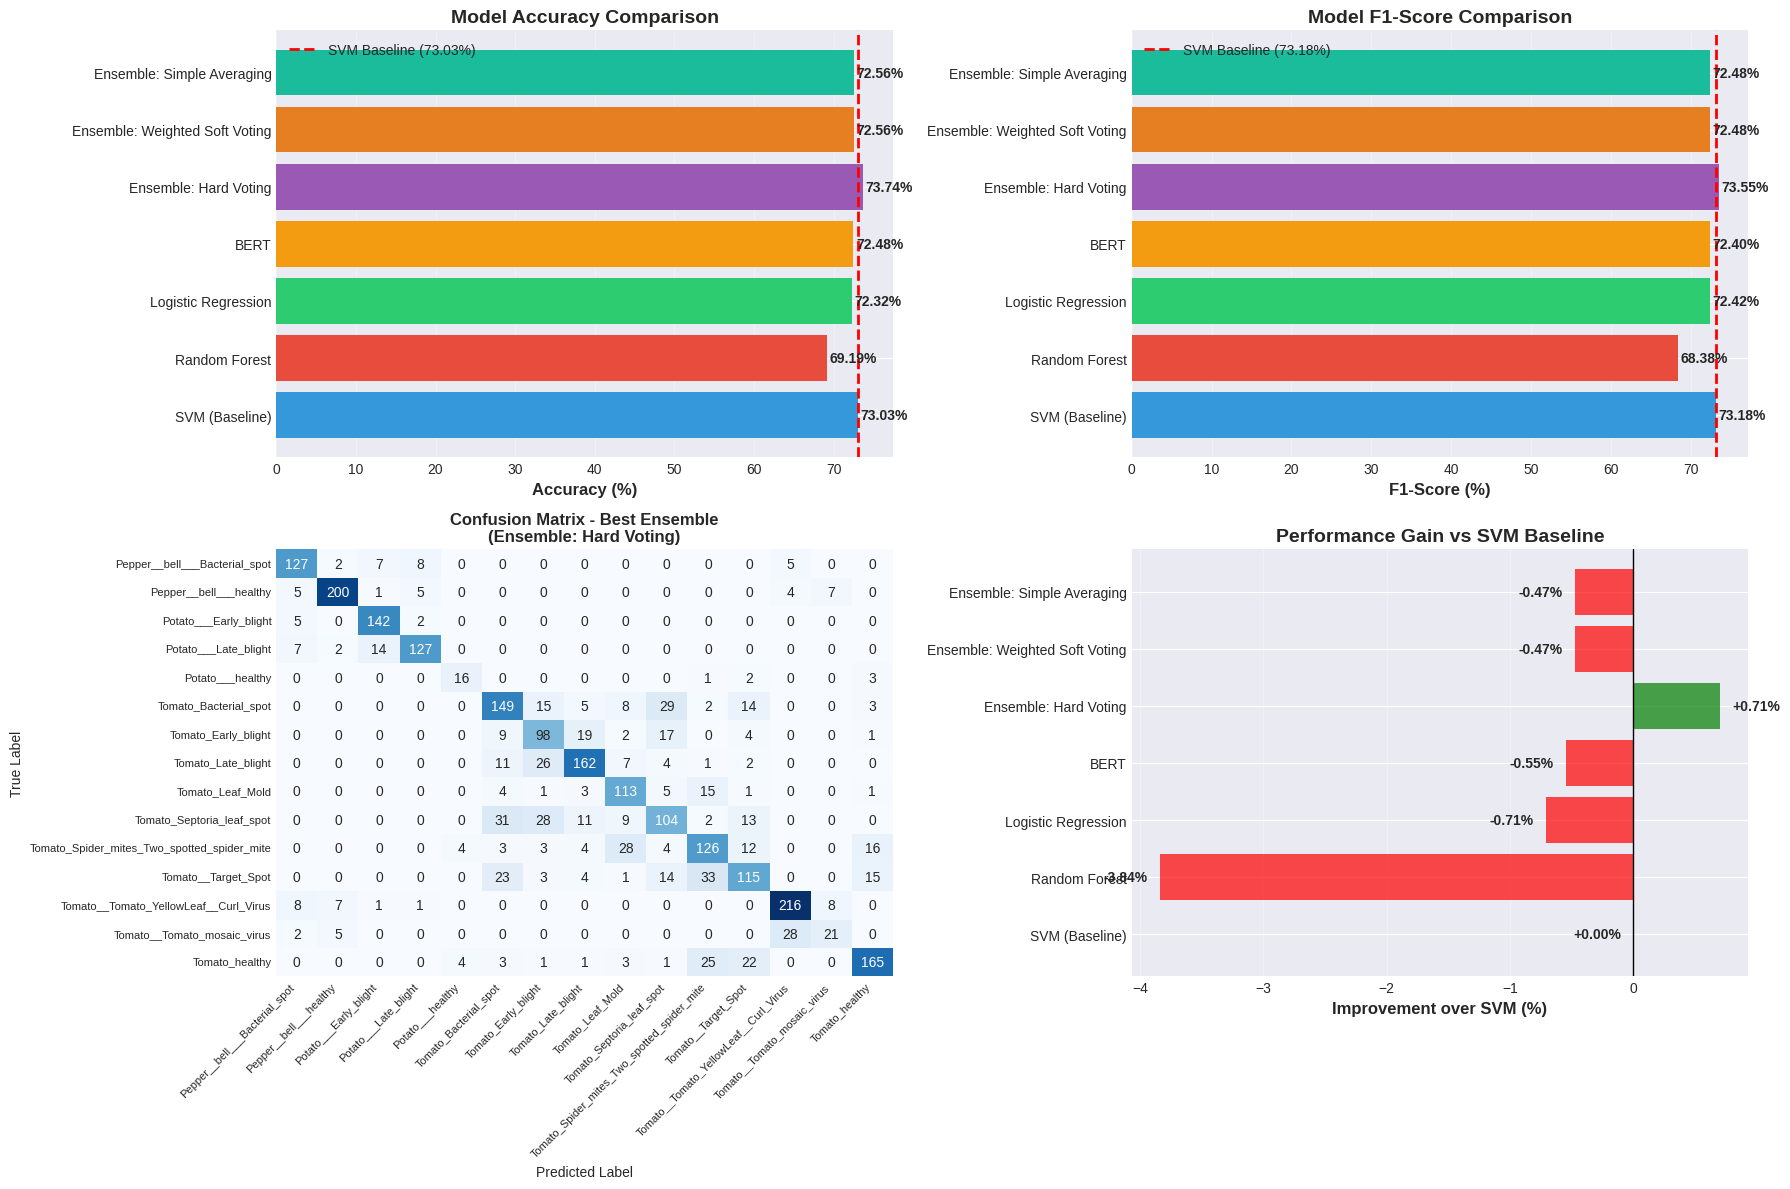

✅ Visualization saved to: /content/drive/MyDrive/LANGUAGE_MODEL_PROJECT/outputs/ensemble_comprehensive_comparison.png

✅ ENSEMBLE ANALYSIS COMPLETED!


In [39]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#e67e22', '#1abc9c']
bars = ax1.barh(plot_data['Model'], plot_data['Accuracy (%)'], color=colors)
ax1.axvline(x=100*svm_acc, color='red', linestyle='--', linewidth=2,
            label=f'SVM Baseline ({100*svm_acc:.2f}%)')
ax1.set_xlabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, plot_data['Accuracy (%)']):
    ax1.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontweight='bold')

# Plot 2: F1-Score Comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(plot_data['Model'], plot_data['F1-Score (%)'], color=colors)
ax2.axvline(x=100*svm_f1, color='red', linestyle='--', linewidth=2,
            label=f'SVM Baseline ({100*svm_f1:.2f}%)')
ax2.set_xlabel('F1-Score (%)', fontsize=12, fontweight='bold')
ax2.set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, plot_data['F1-Score (%)']):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontweight='bold')

# Plot 3: Confusion Matrix for Best Ensemble
ax3 = axes[1, 0]
best_preds = ensemble_soft_preds if soft_voting_acc > hard_voting_acc else ensemble_hard_preds
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=class_names, yticklabels=class_names)
ax3.set_title(f'Confusion Matrix - Best Ensemble\n({best_model})',
              fontsize=12, fontweight='bold')
ax3.set_ylabel('True Label', fontsize=10)
ax3.set_xlabel('Predicted Label', fontsize=10)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax3.get_yticklabels(), rotation=0, fontsize=8)

# Plot 4: Improvement Chart
ax4 = axes[1, 1]
improvements = plot_data['Accuracy (%)'] - 100*svm_acc
colors_imp = ['green' if x > 0 else 'red' for x in improvements]
bars4 = ax4.barh(plot_data['Model'], improvements, color=colors_imp, alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Improvement over SVM (%)', fontsize=12, fontweight='bold')
ax4.set_title('Performance Gain vs SVM Baseline', fontsize=14, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
for bar, val in zip(bars4, improvements):
    ax4.text(val + 0.1 if val > 0 else val - 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:+.2f}%', va='center', ha='left' if val > 0 else 'right',
             fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/ensemble_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Visualization saved to: {OUTPUT_PATH}/ensemble_comprehensive_comparison.png")

print("\n" + "=" * 80)
print("✅ ENSEMBLE ANALYSIS COMPLETED!")
print("=" * 80)